# Entanglement negativity

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 9 — Entanglement and complexity diagnostics*

## 1. Introduction and motivation

For a **pure** state $\vert\psi\rangle_{AB}$ the entanglement question has a complete answer, and we already know it:
compute the reduced density matrix $\rho_A=\mathrm{Tr}_B\vert\psi\rangle\langle\psi\vert$, diagonalise it, and read off the
entanglement entropy $S(\rho_A)$. It is zero exactly when the state is a product, it is maximal exactly when the state is
maximally entangled, and it is the operationally correct answer: $S(\rho_A)$ is the number of Bell pairs per copy that can be
distilled from, or are needed to build, many copies of $\vert\psi\rangle$.

For a **mixed** state this machinery collapses. Consider two spins prepared by a classical coin toss: heads gives
$\vert00\rangle$, tails gives $\vert11\rangle$. The two spins are perfectly correlated, the reduced state of each of them is
maximally mixed, and $S(\rho_A)=1$ bit — the same value as for the Bell state $(\vert00\rangle+\vert11\rangle)/\sqrt2$.
Yet the coin-toss state contains no entanglement at all: it can be prepared by two people who only ever exchanged a telephone
call. The subsystem entropy has stopped measuring entanglement and started measuring ignorance, and it cannot tell the two
apart.

This matters far beyond a toy example. Every experiment produces mixed states; every simulation of an open system produces
mixed states; and — this is the case that drives most of modern many-body physics — **the reduced state of a subsystem of a
pure many-body state is mixed**. If we want to ask how entangled two *blocks* of a spin chain are with each other, with the
rest of the chain traced out, we are asking a mixed-state question even though the chain itself is in a pure ground state.

There is no known efficient quantity that decides mixed-state entanglement in general. Deciding separability is
NP-hard in the dimension of the Hilbert space. What exists instead is a family of *criteria* and *measures* that are
computable, and the most useful of them by a wide margin is the one built from the **partial transpose**: transpose the
density matrix on one subsystem only. Transposition maps states to states, so on its own it is harmless; applied to half of a
composite system it can produce a matrix with negative eigenvalues, and — this is the Peres–Horodecki theorem — that can
only happen if the state is entangled. The total weight of those negative eigenvalues is the **negativity**.

The negativity is attractive for three separate reasons, and every one of them shows up in this notebook:

1. **It is cheap.** No optimisation over decompositions, no variational search: one eigenvalue decomposition.
2. **It is easy to implement.** On a density *tensor* of shape $(2,)^{2N}$ the partial transpose is not index gymnastics at
   all — it is a permutation of axes, one call to `jnp.transpose`.
3. **It is an entanglement monotone**, and its logarithm is additive and bounds the distillable entanglement from above.

**Road map.** Section 3 defines separability and shows on the coin-toss state why subsystem entropy fails. Section 4 derives
the partial transpose as an axis swap and checks that transposing $A$ or $B$ gives the same spectrum. Section 5 proves in one
line that separable implies positive partial transpose, states precisely when the converse holds, and says what bound
entanglement is. Section 6 defines negativity and logarithmic negativity, lists their properties with references, and
verifies the Werner threshold $v>1/3$ and the two-qubit relation to Wootters' concurrence. Section 7 derives the closed-form
negativity of a *pure* state from its Schmidt coefficients and identifies the logarithmic negativity with a Renyi entropy of
index $1/2$; the zoo (GHZ, W, Dicke, random) is checked against both the formula and the brute-force partial transpose.
Section 8 contrasts negativity with entropy on noisy Bell and GHZ states. Section 9 is the many-body application: the
negativity between two disjoint blocks of the transverse-field Ising ground state, as a function of their distance and of the
field. Section 10 is dynamics: the light cone of block negativity after a quench, and entanglement sudden death under local
noise. Section 11 counts the cost.

### What you will learn

*Physics*

* what separable means for a mixed state, and why $S(\rho_A)$ is the wrong question to ask about one;
* the Peres–Horodecki (PPT) criterion, its proof, its exact range of validity, and bound entanglement;
* negativity and logarithmic negativity: definitions, monotonicity, additivity, and the bound on distillable entanglement;
* the Werner threshold $v>1/3$, the noisy-GHZ thresholds, and the fact that a state's *global* entropy can keep growing long
  after its entanglement has died;
* how entanglement between two blocks of a spin chain depends on their separation and on the transverse field, and what
  happens to it after a quench and under local decoherence (entanglement sudden death).

*Numerical methods*

* the partial transpose as an axis permutation of a rank-$2N$ tensor, and why that is exact and free;
* the pure-state shortcut $\mathcal N=\tfrac12[(\sum_k\lambda_k)^2-1]$ from the singular values, which replaces an
  $O(8^N)$ eigenvalue problem by an $O(2^N)$ SVD;
* the reduced-density-matrix route to block negativity: trace out everything outside $A\cup B$ first, then transpose — cost
  set by $\vert A\vert+\vert B\vert$, not by $N$;
* Lanczos ground states and TEBD reused from Chapter 5, density-tensor Lindblad dynamics reused from Chapter 6.

*Implementation practice*

* validating every new function against an independent reference (analytic formula, brute-force partial transpose,
  dense diagonalisation) before using it;
* `jax.jit` + `lax.scan` for the noisy dynamics, `jax.vmap` for the sudden-death parameter scan;
* keeping the density tensor out of the calculation whenever a small reduced density matrix suffices.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) and
  [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb);
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, Schmidt decomposition, entanglement entropy;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, partial trace, Kraus channels, and — used constantly below — the difference between a *positive* and a
  *completely positive* map;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)
  and [12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) for Section 9 and Section 10;
* [21 — entanglement swapping and superdense coding](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb):
  Werner states and the concurrence appear there as tools; here they are the subject.

**Conventions.** Qubit $q$ = tensor axis $q$, counted from $0$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. A density
*tensor* of $N$ qubits has rank $2N$: axes $0,\dots,N-1$ carry the ket indices and axes $N,\dots,2N-1$ the bra indices, so
that $\rho[s_0\ldots s_{N-1};s'_0\ldots s'_{N-1}]=\langle s_0\ldots s_{N-1}\vert\rho\vert s'_0\ldots s'_{N-1}\rangle$.
All entropies are in bits.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

From the engine we need the einsum primitives, the reduced density matrices, the channels, the partial transpose and the
negativity itself, plus the ground-state and time-evolution machinery of Chapter 5. Everything specific to this notebook is
written below in the same style.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho

def tebd_evolve(psi, terms, dt, n_steps, order=2, observe=None):
    """Evolve for n_steps*dt with TEBD and record `observe(psi)` after every step.

    JAX    `lax.scan(step, carry, xs, length)` compiles the step ONCE and loops inside XLA
           (a Python for-loop under jit would unroll n_steps copies of the graph).
           Returns (final_state, stacked_observables).
    """
    gates = tebd_gates(terms, dt, order)

    def step(psi, _):
        psi = apply_gates(psi, gates)
        return psi, (observe(psi) if observe is not None else 0.0)

    return lax.scan(step, psi, None, length=n_steps)

def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


In [3]:
# ==============================================================================
# PLOT STYLE + helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def dm_tensor(mat, N):
    """Inverse of `dm_matrix`: view a 2^N x 2^N matrix as a rank-2N density tensor.

    MATH   rho[s_0..s_{N-1}; s'_0..s'_{N-1}] = <s_0..s_{N-1}| rho |s'_0..s'_{N-1}>
           The flat row index is C-ordered with qubit 0 as the most significant bit, so the reshape
           (2^N, 2^N) -> (2,)*2N puts the ket indices on axes 0..N-1 and the bra indices on axes N..2N-1.
    """
    return jnp.asarray(mat, dtype=CDTYPE).reshape((2,) * (2 * N))


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def neg_of_matrix(rho_mat, n_A, n_B):
    """Negativity of a bipartite density MATRIX of (n_A + n_B) qubits, transposing the first n_A of them.

    MATH   N(rho) = (||rho^{T_A}||_1 - 1)/2.
    IMPLEMENTATION  reshape the matrix to a rank-2(n_A+n_B) tensor and call the engine's `negativity`,
           which swaps the ket/bra axes of A and diagonalises.  Returns (N, E_N).
    """
    n = n_A + n_B
    neg, log_neg = negativity(dm_tensor(rho_mat, n), list(range(n_A)))
    return float(neg), float(log_neg)


def block_negativity(psi, A, B):
    """Negativity between two disjoint sets of qubits A and B of a PURE state `psi`.

    MATH   rho_{AB} = Tr_{rest} |psi><psi| ;   N = (|| rho_{AB}^{T_A} ||_1 - 1)/2.
           A and B need not be adjacent and need not cover the chain: everything outside A u B is traced out,
           which is exactly what makes rho_{AB} mixed and the question non-trivial.
    COST   O(2^N 2^{|A|+|B|}) for the reduced density matrix + O(8^{|A|+|B|}) for its eigenvalues --
           independent of N in the second term, which is why N = 12 spins with |A|=|B|=2 is easy.
    """
    A, B = tuple(int(q) for q in A), tuple(int(q) for q in B)
    rho_AB = rdm(psi, A + B)
    return neg_of_matrix(rho_AB, len(A), len(B))


def concurrence(rho_mat):
    """Wootters' concurrence of a TWO-qubit density matrix (Phys. Rev. Lett. 80, 2245 (1998)).

    MATH   spin-flipped state   rho~ = (Y (x) Y) rho^* (Y (x) Y)
           lambda_1 >= ... >= lambda_4 = square roots of the eigenvalues of rho rho~
           C(rho) = max(0, lambda_1 - lambda_2 - lambda_3 - lambda_4).
    IMPLEMENTATION  rho rho~ is not Hermitian; we use the similar Hermitian matrix sqrt(rho) rho~ sqrt(rho),
           which has the SAME eigenvalues and can be handled by the stable `eigvalsh`.
    """
    YY_ = jnp.kron(Y, Y)
    rho_mat = jnp.asarray(rho_mat, dtype=CDTYPE)
    rho_tilde = YY_ @ jnp.conj(rho_mat) @ YY_
    s = _sqrtm_psd(rho_mat)
    lam = jnp.sqrt(jnp.clip(jnp.linalg.eigvalsh(s @ rho_tilde @ s), 0.0, None))   # ascending
    return float(jnp.maximum(0.0, lam[3] - lam[2] - lam[1] - lam[0]))


print("helpers defined; TOL =", TOL)

helpers defined; TOL = 1e-10


## 3. Separable and entangled mixed states

### 3.1 The definition

A bipartite mixed state $\rho_{AB}$ is **separable** if it can be written as a convex combination of product states,

$$\rho_{AB}=\sum_k p_k\,\rho_A^{(k)}\otimes\rho_B^{(k)},\qquad p_k\ge0,\quad\sum_kp_k=1 , \tag{1}$$

where $\rho_A^{(k)}$ and $\rho_B^{(k)}$ are ordinary states of $A$ and of $B$. If no such decomposition exists, the state is
**entangled**.

Eq. (1) is a statement about *preparability*. A separable state is exactly a state that Alice and Bob can prepare with local
operations and classical communication: they draw a label $k$ from a shared random number generator (that is the classical
communication), Alice prepares $\rho_A^{(k)}$ in her laboratory, Bob prepares $\rho_B^{(k)}$ in his, and neither of them ever
touches the other's system. Anything that cannot be built this way needs a genuinely quantum interaction at some point in its
history, and *that* is what we call entanglement.

Eq. (1) also explains why the problem is hard. To prove a state separable you must *exhibit* one decomposition out of an
infinite family; to prove it entangled you must rule out all of them. There is no bound on the number of terms $k$ that a
decomposition might need. The general decision problem is NP-hard in the dimension (Gurvits, 2003), so what we look for below
are computable *sufficient* conditions for entanglement.

### 3.2 Two states with the same subsystem entropy

The classical coin toss of Section 1 is

$$\rho_{\rm coin}=\tfrac12\vert00\rangle\langle00\vert+\tfrac12\vert11\rangle\langle11\vert , \tag{2}$$

which is literally of the form (1) with two terms, $p_1=p_2=\tfrac12$, $\rho_A^{(1)}\otimes\rho_B^{(1)}=
\vert0\rangle\langle0\vert\otimes\vert0\rangle\langle0\vert$ and likewise for $\vert11\rangle$. It is separable by
construction. Compare it with the Bell state

$$\vert\Phi^+\rangle=\tfrac{1}{\sqrt2}(\vert00\rangle+\vert11\rangle),\qquad
  \rho_{\rm Bell}=\vert\Phi^+\rangle\langle\Phi^+\vert .$$

Both have the same diagonal in the computational basis; they differ only in the two off-diagonal entries
$\rho_{00,11}=\rho_{11,00}=\tfrac12$, which the coin toss lacks. Tracing out qubit $1$ kills exactly those entries in both
cases, so $\rho_A$ is $\tfrac12\mathbb 1$ for both, and $S(\rho_A)=1$ bit for both. The next cell prints the four numbers.

In [4]:
# ==============================================================================
# STEP 1: the coin-toss state and the Bell state -- same reduced state, different entanglement
# ==============================================================================
rho_coin = dm_tensor(jnp.diag(jnp.array([0.5, 0.0, 0.0, 0.5], dtype=CDTYPE)), 2)
rho_bell = to_dm(bell_state("phi+"))

print(f"{'state':>12s}  {'S(rho_A) [bit]':>14s}  {'S(rho_AB) [bit]':>15s}  {'purity':>8s}  {'negativity':>10s}")
for name, rho in [("coin toss", rho_coin), ("Bell", rho_bell)]:
    S_A = float(von_neumann_entropy(rdm_dm(rho, [0])))
    S_AB = float(von_neumann_entropy(dm_matrix(rho)))
    pur = float(purity(dm_matrix(rho)))
    neg = float(negativity(rho, [0])[0])
    print(f"{name:>12s}  {S_A:14.6f}  {S_AB:15.6f}  {pur:8.4f}  {neg:10.6f}")

print("\nreduced state of qubit 0, coin toss:\n", np.round(np.asarray(rdm_dm(rho_coin, [0])), 6))
print("reduced state of qubit 0, Bell    :\n", np.round(np.asarray(rdm_dm(rho_bell, [0])), 6))

       state  S(rho_A) [bit]  S(rho_AB) [bit]    purity  negativity


   coin toss        1.000000         1.000000    0.5000    0.000000
        Bell        1.000000         0.000000    1.0000    0.500000

reduced state of qubit 0, coin toss:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
reduced state of qubit 0, Bell    :
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


The two reduced states are the same matrix $\tfrac12\mathbb 1$ to machine precision, and both give $S(\rho_A)=1$ bit. What
separates the two rows is the *global* entropy: the Bell state is pure, $S(\rho_{AB})=0$, while the coin toss has
$S(\rho_{AB})=1$ bit. The last column is the quantity this notebook is about, and it already does the right thing: $0$ for the
separable state, $1/2$ for the Bell state.

> **Physics insight.** For a *pure* $\rho_{AB}$ the subsystem entropy works because the only way a part can be mixed is
> through entanglement with the rest — there is no other source of ignorance. As soon as $\rho_{AB}$ is itself mixed, a
> subsystem is mixed for two reasons at once (entanglement and classical ignorance), and $S(\rho_A)$ adds them up without
> distinguishing them. The combination $S(\rho_B)-S(\rho_{AB})$, called the coherent information $I(A\rangle B)$, subtracts
> part of the classical contribution; for the two states here $S(\rho_A)=S(\rho_B)$, so it equals
> $S(\rho_A)-S(\rho_{AB})$, which is $+1$ bit for the Bell state and $0$ for the coin toss. It can be negative and is not
> an entanglement measure either. We need a different idea.

## 4. The partial transpose

### 4.1 Definition

Write a bipartite density matrix in a product basis $\vert i\rangle_A\vert k\rangle_B$:

$$\rho=\sum_{i,j,k,l}\rho_{ik,jl}\,\vert i\rangle\langle j\vert_A\otimes\vert k\rangle\langle l\vert_B .$$

The **partial transpose with respect to $A$** transposes only the $A$ indices and leaves the $B$ indices alone:

$$\rho^{T_A}=\sum_{i,j,k,l}\rho_{ik,jl}\,\vert j\rangle\langle i\vert_A\otimes\vert k\rangle\langle l\vert_B ,
  \qquad\text{equivalently}\qquad (\rho^{T_A})_{ik,jl}=\rho_{jk,il} . \tag{3}$$

Eq. (3) reads as follows: on the left the row label is $(i,k)$ and the column label is $(j,l)$; on the right the $A$ parts of
the two labels, $i$ and $j$, have been exchanged, while the $B$ parts $k$ and $l$ stay where they are.

### 4.2 On a density tensor it is a permutation of axes

Our density tensor already has the four groups of indices separated: axis $q$ is the ket index of qubit $q$, axis $N+q$ is its
bra index. Take $A=\{q_1,\dots,q_m\}$. Eq. (3) says: exchange the ket and bra index of every qubit in $A$, and touch nothing
else. In tensor language that is

$$\rho^{T_A}[\ldots s_q\ldots;\ldots s'_q\ldots]=\rho[\ldots s'_q\ldots;\ldots s_q\ldots]\quad\text{for }q\in A ,$$

a permutation of the axes of the array — no arithmetic at all. For $N=2$ and $A=\{0\}$ the axes are
$(\text{ket}_0,\text{ket}_1,\text{bra}_0,\text{bra}_1)=(0,1,2,3)$ and the permutation is $(2,1,0,3)$; the einsum spelling is
`"abAB->AbaB"`. The engine's `partial_transpose` builds this permutation for any subset and calls `jnp.transpose`:

```python
rho = as_dm_tensor(rho)          # a (2^N, 2^N) matrix is reshaped to the rank-2N tensor first
N = rho.ndim // 2
perm = list(range(2 * N))
for q in qubits:
    perm[q], perm[N + q] = perm[N + q], perm[q]
return jnp.transpose(rho, perm)
```

On a $2^N\times2^N$ *matrix* the same operation is a nuisance — one has to decode the composite row and column indices bit by
bit. The tensor layout makes it free, and this is a recurring theme of these notes: choosing the right index layout turns
index gymnastics into a one-line array operation.

In [5]:
# ==============================================================================
# STEP 2: the partial transpose, three ways, on a deliberately generic 2-qubit state
# ==============================================================================
# A generic (non-symmetric, complex) mixed state, so that the three implementations really can disagree.
key = jax.random.PRNGKey(0)
G = jax.random.normal(key, (4, 3)) + 1j * jax.random.normal(jax.random.fold_in(key, 1), (4, 3))
rho_mat = G @ G.conj().T
rho_mat = rho_mat / jnp.trace(rho_mat)                       # a rank-3 mixed state of 2 qubits
rho_t = dm_tensor(rho_mat, 2)

# (a) engine: axis permutation of the rank-4 tensor
pt_engine = dm_matrix(partial_transpose(rho_t, [0]))

# (b) the same thing written out as an einsum:  rho^{T_A}[a,b,A,B] = rho[A,b,a,B]
pt_einsum = dm_matrix(jnp.einsum("abAB->AbaB", rho_t))

# (c) brute force on the 4x4 matrix, straight from Eq. (3): (rho^{T_A})_{ik,jl} = rho_{jk,il}
pt_loop = np.zeros((4, 4), dtype=complex)
R = np.asarray(rho_mat)
for i in range(2):
    for k in range(2):
        for j in range(2):
            for l in range(2):
                pt_loop[2 * i + k, 2 * j + l] = R[2 * j + k, 2 * i + l]

print("engine vs einsum      :", max_abs(pt_engine - pt_einsum))
print("engine vs explicit loop:", max_abs(pt_engine - jnp.asarray(pt_loop)))
assert max_abs(pt_engine - pt_einsum) < TOL and max_abs(pt_engine - jnp.asarray(pt_loop)) < TOL

# The partial transpose is Hermiticity- and trace-preserving, but NOT positivity-preserving.
print("\nHermitian?          ", max_abs(pt_engine - pt_engine.conj().T) < TOL)
print("trace preserved?    ", abs(float(jnp.real(jnp.trace(pt_engine))) - 1.0) < TOL)
print("eigenvalues of rho  :", np.round(np.linalg.eigvalsh(np.asarray(rho_mat)), 6))
print("eigenvalues of rho^T_A:", np.round(np.linalg.eigvalsh(np.asarray(pt_engine)), 6))

# WRONG CONTROL: transposing the whole 4x4 matrix instead of the A axes only.  The full transpose has the
# spectrum of rho itself, so it reports zero negativity for every state -- even for the Bell state.
bell_mat = dm_matrix(to_dm(bell_state("phi+")))
mu_full = np.linalg.eigvalsh(np.asarray(bell_mat.T))
mu_part = np.linalg.eigvalsh(np.asarray(dm_matrix(partial_transpose(bell_mat, [0]))))   # matrix input is accepted
print("\nBell state, full transpose   : eigenvalues", np.round(mu_full, 6),
      f"-> negativity {np.sum(np.abs(mu_full) - mu_full) / 2:.6f}")
print("Bell state, partial transpose: eigenvalues", np.round(mu_part, 6),
      f"-> negativity {np.sum(np.abs(mu_part) - mu_part) / 2:.6f}")
assert mu_full.min() > -TOL and abs(mu_part.min() + 0.5) < TOL

engine vs einsum      : 0.0
engine vs explicit loop: 0.0

Hermitian?           True
trace preserved?     True
eigenvalues of rho  : [0.       0.04982  0.257874 0.692306]
eigenvalues of rho^T_A: [-0.190568  0.268618  0.37495   0.547   ]

Bell state, full transpose   : eigenvalues [0. 0. 0. 1.] -> negativity 0.000000
Bell state, partial transpose: eigenvalues [-0.5  0.5  0.5  0.5] -> negativity 0.500000


Three independent implementations agree to machine precision, so Eq. (3) and the axis permutation really are the same
operation. The partial transpose keeps Hermiticity and the trace, so its eigenvalues are real and sum to $1$ — but for this
particular entangled state one of them came out negative, and a matrix with a negative eigenvalue is not a density matrix.

The last two lines are a control that must fail. Transposing the *whole* $4\times4$ matrix of the Bell state gives back the
spectrum of $\rho$ itself, $(0,0,0,1)$, and therefore zero negativity, while the partial transpose gives
$(-\tfrac12,\tfrac12,\tfrac12,\tfrac12)$.

> **Common pitfall.** `rdm` and `dm_matrix` return a $2^N\times2^N$ *matrix*, and the channel functions work with the
> rank-$2N$ *tensor*. Swapping "axis $q$ with axis $N+q$" on the matrix form means swapping its only two axes, which is the
> full transpose: the eigenvalues do not change, and the negativity comes out as exactly zero with no error message. The
> engine's `partial_transpose` therefore reshapes a matrix to the tensor first (`as_dm_tensor`). In this notebook every
> conversion is also written out explicitly with `dm_tensor`, so each call site shows which layout it passes. When a
> negativity is exactly zero for a state you expect to be entangled, test the code on a Bell state first.

### 4.3 Transposing $A$ or transposing $B$ gives the same spectrum

Full transposition of the whole matrix is $\rho\mapsto\rho^{\mathsf T}$, and since $\rho$ is Hermitian,
$\rho^{\mathsf T}=\rho^*$ — the complex conjugate. Now observe

$$\rho^{T_B}=\left(\rho^{T_A}\right)^{\mathsf T} ,$$

because transposing $A$ and then transposing everything is the same as transposing $B$ alone. Transposition does not change
eigenvalues (the characteristic polynomial is invariant, $\det(M^{\mathsf T}-\lambda\mathbb 1)=\det(M-\lambda\mathbb 1)$), so

$$\mathrm{spec}\,\rho^{T_A}=\mathrm{spec}\,\rho^{T_B} .$$

Every quantity built from that spectrum — in particular the negativity — is therefore independent of which side we transpose.
This is not a cosmetic remark: it means that for a bipartition into a small block $A$ and a huge block $B$ we may always
transpose the *small* side, and the code never has to think about it.

In [6]:
# ==============================================================================
# STEP 3: spec(rho^{T_A}) == spec(rho^{T_B}) on a random 4-qubit mixed state
# ==============================================================================
key = jax.random.PRNGKey(7)
G4 = jax.random.normal(key, (16, 6)) + 1j * jax.random.normal(jax.random.fold_in(key, 1), (16, 6))
rho4 = G4 @ G4.conj().T
rho4 = dm_tensor(rho4 / jnp.trace(rho4), 4)

lam_A = np.sort(np.linalg.eigvalsh(np.asarray(dm_matrix(partial_transpose(rho4, [0, 1])))))
lam_B = np.sort(np.linalg.eigvalsh(np.asarray(dm_matrix(partial_transpose(rho4, [2, 3])))))
print("largest |spec(T_A) - spec(T_B)| =", np.max(np.abs(lam_A - lam_B)))
print("negativity from T_A:", f"{negativity(rho4, [0, 1])[0]:.10f}")
print("negativity from T_B:", f"{negativity(rho4, [2, 3])[0]:.10f}")
assert np.max(np.abs(lam_A - lam_B)) < TOL

largest |spec(T_A) - spec(T_B)| = 0.0
negativity from T_A: 0.3557209339
negativity from T_B: 0.3557209339


## 5. The PPT criterion

### 5.1 Separable implies positive partial transpose

This is the whole idea, and the proof is one line. Insert the separable form (1) into the partial transpose. Transposition is
linear, and on a product $\rho_A^{(k)}\otimes\rho_B^{(k)}$ it acts only on the first factor:

$$\rho^{T_A}=\sum_kp_k\left(\rho_A^{(k)}\right)^{\mathsf T}\otimes\rho_B^{(k)} . \tag{4}$$

Each $\left(\rho_A^{(k)}\right)^{\mathsf T}$ is a transposed density matrix, hence Hermitian with the *same* (non-negative)
eigenvalues as $\rho_A^{(k)}$; it is therefore itself a legitimate density matrix. A tensor product of two positive operators
is positive, a convex combination of positive operators is positive, and so $\rho^{T_A}\ge0$. $\square$

Contrapositive, and this is how the criterion is used:

> **If $\rho^{T_A}$ has a negative eigenvalue, then $\rho$ is entangled.**

This is the **Peres criterion** (Peres, 1996). It is a *sufficient* condition for entanglement and a *necessary* condition for
separability; states with $\rho^{T_A}\ge0$ are called **PPT** (positive partial transpose).

### 5.2 Why a negative eigenvalue is possible at all

Transposition maps every density matrix to a density matrix: it is a **positive** map. If it were also **completely
positive** — that is, if $\mathsf T\otimes\mathrm{id}_R$ were positive for a spectator system $R$ of every dimension — then
Eq. (3) could never produce a negative eigenvalue, for any state at all. Transposition is the standard example of a map that
is positive but not completely positive, exactly as discussed in
[07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb).
The partial transpose is that map applied to half of a bipartite system, which is precisely the situation in which the
distinction becomes visible.

So the PPT criterion is not a trick: it *is* the statement "transposition is positive but not completely positive", turned
into a test. Entangled states are exactly the states that can feel the difference.

### 5.3 When PPT is also sufficient

The converse of Section 5.1 — PPT implies separable — is **true in exactly two cases**:

> **Theorem (Horodecki, Horodecki and Horodecki, 1996).** For bipartite systems of dimensions $2\times2$ and $2\times3$, a
> state is separable if and only if its partial transpose is positive.

In every larger pair of dimensions, $2\times4$, $3\times3$ and beyond, the converse fails: there exist entangled states whose
partial transpose is positive. We quote the theorem without proof; its proof rests on the characterisation of positive maps on
low-dimensional matrix algebras (Størmer; Woronowicz), which is well outside this course.

For us this has a very concrete consequence. Two qubits, and one qubit against one qutrit, are the only cases in which
"negativity $=0$" *proves* separability. For a pair of two-qubit blocks ($4\times4$) — the main object of Section 9 — a
vanishing negativity proves nothing at all; it only means that this particular criterion has not detected entanglement.

### 5.4 Bound entanglement

The entangled PPT states are not a curiosity. P. Horodecki (1997) constructed the first examples in $2\times4$ and $3\times3$,
and the Horodecki family then showed (1998) that **no** PPT state can be distilled: no matter how many copies you have and how
cleverly you act locally, you cannot extract a single Bell pair from a PPT state. Such states are called **bound entangled** —
entanglement went in when they were made, and none of it can be taken out again in the usual currency.

This is also why the negativity, which vanishes on every PPT state, cannot be the whole story: it is blind to bound
entanglement by construction, so outside $2\times2$ and $2\times3$ a vanishing negativity never certifies separability. In the
opposite direction the next section makes precise what a *non*-vanishing negativity is worth: its logarithm is an **upper**
bound on the number of Bell pairs that can be distilled from the state.

## 6. Negativity and logarithmic negativity

### 6.1 Definitions

For a Hermitian matrix $M$ the trace norm is $\lVert M\rVert_1=\mathrm{Tr}\sqrt{M^\dagger M}=\sum_i\vert\mu_i\vert$, the sum
of the absolute values of the eigenvalues. Since $\mathrm{Tr}\,\rho^{T_A}=\mathrm{Tr}\,\rho=1$, writing the eigenvalues of
$\rho^{T_A}$ as $\mu_i$ and splitting them into positive and negative ones gives

$$\lVert\rho^{T_A}\rVert_1=\sum_{\mu_i>0}\mu_i-\sum_{\mu_i<0}\mu_i
 =\underbrace{\sum_i\mu_i}_{=1}-2\sum_{\mu_i<0}\mu_i=1+2\sum_{\mu_i<0}\vert\mu_i\vert .$$

The **negativity** and the **logarithmic negativity** are

$$\mathcal N(\rho)=\frac{\lVert\rho^{T_A}\rVert_1-1}{2}=\sum_{\mu_i<0}\vert\mu_i\vert ,
  \qquad
  E_{\mathcal N}(\rho)=\log_2\lVert\rho^{T_A}\rVert_1=\log_2\bigl(2\mathcal N(\rho)+1\bigr) . \tag{5}$$

So $\mathcal N$ is literally the total weight of the negative eigenvalues of the partial transpose. It is $0$ for every PPT
state — in particular for every separable state — and positive exactly when the Peres test fires. The name "negativity" is due
to Vidal and Werner (2002); the quantity itself, as $\lVert\rho^{T_A}\rVert_1-1=2\mathcal N$, first appeared in Życzkowski,
Horodecki, Sanpera and Lewenstein (1998), who defined it as a "degree of entanglement" and averaged it over random density
matrices in their study of the volume of the set of separable states.

### 6.2 Properties, and where they come from

The following are quoted, not proved here; each is a theorem of the reference given.

* **Entanglement monotone.** $\mathcal N$ does not increase under local operations and classical communication
  (Vidal and Werner, 2002, who prove monotonicity for $\mathcal N$). This is what makes it an entanglement *measure* and not
  merely a detector.
* **Convexity, and the status of $E_{\mathcal N}$.** $\mathcal N$ is convex:
  $\mathcal N(\sum_kp_k\rho_k)\le\sum_kp_k\mathcal N(\rho_k)$, because $\lVert\cdot\rVert_1$ is a norm and the partial
  transpose is linear. $E_{\mathcal N}$ is **not** convex, since $\log_2$ is concave and destroys the inequality — Exercise 5
  constructs an explicit violation. That it is nevertheless a full entanglement monotone is a separate and later theorem:
  Plenio (2005) showed that $E_{\mathcal N}$ does not increase *on average* under PPT operations, a class that contains LOCC.
  The 2002 paper proves monotonicity for $\mathcal N$ and, for $E_{\mathcal N}$, only that it does not increase under
  deterministic LOCC protocols; monotonicity on average is Plenio's theorem.
* **Additivity.** $E_{\mathcal N}(\rho_1\otimes\rho_2)=E_{\mathcal N}(\rho_1)+E_{\mathcal N}(\rho_2)$, immediately from
  $(\rho_1\otimes\rho_2)^{T_A}=\rho_1^{T_A}\otimes\rho_2^{T_A}$ and the multiplicativity of the trace norm on tensor
  products. This is the reason to take the logarithm at all: $E_{\mathcal N}$ is measured in ebits and simply adds up over
  independent pairs, while $\mathcal N$ does not.
* **Bound on distillable entanglement.** $E_D(\rho)\le E_{\mathcal N}(\rho)$ (Vidal and Werner, 2002): the logarithmic
  negativity is an upper bound on the number of Bell pairs per copy that can be distilled from $\rho$ by local operations and
  classical communication.
* **Normalisation.** For the maximally entangled state of two $d$-dimensional systems,
  $\mathcal N=(d-1)/2$ and $E_{\mathcal N}=\log_2 d$. For two qubits ($d=2$) that is $\mathcal N=1/2$ and
  $E_{\mathcal N}=1$ ebit — the value printed for the Bell state in Section 3.

We verify additivity and the Bell normalisation numerically before using them.

In [7]:
# ==============================================================================
# STEP 4: additivity of E_N and the maximally-entangled normalisation
# ==============================================================================
# Two independent noisy Bell pairs on qubits (0,1) and (2,3); A = {0,2}, B = {1,3}.
def werner_matrix(v):
    """Werner / isotropic two-qubit state  rho_W = v |Phi+><Phi+| + (1-v) 1/4  as a 4x4 matrix."""
    b = jnp.asarray(bell_state("phi+")).reshape(4)
    return v * jnp.outer(b, jnp.conj(b)) + (1 - v) * jnp.eye(4, dtype=CDTYPE) / 4


rho1, rho2 = werner_matrix(0.9), werner_matrix(0.6)
n1, e1 = neg_of_matrix(rho1, 1, 1)
n2, e2 = neg_of_matrix(rho2, 1, 1)

# tensor product of the two pairs, reordered so that A = {0,2} sits on axes 0,1
rho_pair = jnp.kron(rho1, rho2)                                  # qubit order (0,1,2,3)
rho_pair_t = dm_tensor(rho_pair, 4)
n12, e12 = float(negativity(rho_pair_t, [0, 2])[0]), float(negativity(rho_pair_t, [0, 2])[1])

print(f"E_N(pair 1)            = {e1:.10f}")
print(f"E_N(pair 2)            = {e2:.10f}")
print(f"E_N(pair 1) + E_N(2)   = {e1 + e2:.10f}")
print(f"E_N(pair 1 (x) pair 2) = {e12:.10f}   -> additive to {abs(e12 - e1 - e2):.2e}")
print(f"N(pair 1) + N(pair 2)  = {n1 + n2:.10f}   (N itself is NOT additive: N(1(x)2) = {n12:.10f})")
print(f"2 N1 N2 + N1 + N2      = {2 * n1 * n2 + n1 + n2:.10f}   (prediction from ||.||_1 = 2N + 1 being multiplicative)")
assert abs(e12 - e1 - e2) < 1e3 * TOL and abs(n12 - (2 * n1 * n2 + n1 + n2)) < 1e3 * TOL
assert abs(n12 - (n1 + n2)) > 0.1                  # control: the additivity of N itself must FAIL

nb, eb = neg_of_matrix(dm_matrix(rho_bell), 1, 1)
print(f"\nBell state: N = {nb:.10f} (expected 1/2),  E_N = {eb:.10f} ebit (expected 1)")
assert abs(nb - 0.5) < 1e3 * TOL and abs(eb - 1.0) < 1e3 * TOL

E_N(pair 1)            = 0.8875252707
E_N(pair 2)            = 0.4854268272
E_N(pair 1) + E_N(2)   = 1.3729520979
E_N(pair 1 (x) pair 2) = 1.3729520979   -> additive to 3.89e-16
N(pair 1) + N(pair 2)  = 0.6250000000   (N itself is NOT additive: N(1(x)2) = 0.7950000000)
2 N1 N2 + N1 + N2      = 0.7950000000   (prediction from ||.||_1 = 2N + 1 being multiplicative)

Bell state: N = 0.5000000000 (expected 1/2),  E_N = 1.0000000000 ebit (expected 1)


$E_{\mathcal N}$ adds to machine precision while $\mathcal N$ does not: $\mathcal N_1+\mathcal N_2=0.625$, but the pair of
pairs has $\mathcal N=0.795=2\mathcal N_1\mathcal N_2+\mathcal N_1+\mathcal N_2$, which is exactly what
$2\mathcal N+1=\lVert\cdot\rVert_1$ and the multiplicativity of the trace norm predict. The Bell state sits at $\mathcal N=1/2$, $E_{\mathcal N}=1$ ebit.

### 6.3 Werner states and the threshold $v=1/3$

The standard one-parameter family of noisy two-qubit states is the Werner (isotropic) state of visibility $v$, as in
[notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb), Section 11:

$$\rho_W(v)=v\,\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v)\,\frac{\mathbb 1_4}{4},\qquad v\in[0,1] . \tag{6}$$

Werner's own family (Werner, 1989) mixes the *singlet* $\vert\Psi^-\rangle$ with $\mathbb 1/4$, and the family written above
is strictly the *isotropic* state. For two qubits the two are the same set: $\vert\Phi^+\rangle$ and $\vert\Psi^-\rangle$
differ by a local unitary, and $\mathbb 1/4$ is invariant under any local unitary, so every quantity used here takes the same
value on both (Exercise 3). The two names are used interchangeably below, as they are in most of the literature on qubits.

Its partial transpose can be diagonalised by hand. Since $(\mathbb 1/4)^{T_A}=\mathbb 1/4$ and, as printed in Section 4,
$\vert\Phi^+\rangle\langle\Phi^+\vert^{T_A}$ has eigenvalues $(\tfrac12,\tfrac12,\tfrac12,-\tfrac12)$, linearity gives

$$\mathrm{spec}\,\rho_W^{T_A}=\left\{\frac{1+v}{4}\ (\times3),\ \frac{1-3v}{4}\right\} ,$$

so the single eigenvalue $\tfrac{1-3v}{4}$ is negative exactly when $v>1/3$, and

$$\mathcal N(\rho_W)=\max\left(0,\ \frac{3v-1}{4}\right) . \tag{7}$$

Because two qubits are a $2\times2$ system, Section 5.3 applies: $\rho_W$ is **entangled if and only if $v>1/3$**. This is one
of the few cases in all of entanglement theory where a sharp necessary-and-sufficient statement is available in closed form,
and it is why Werner states are used as the standard benchmark throughout these notes.

max |N(numeric) - (3v-1)/4| = 2.220e-16
first grid point with N > 0: v = 0.340  (exact threshold 1/3 = 0.333)
v = 1/3 exactly: N = 0.000e+00


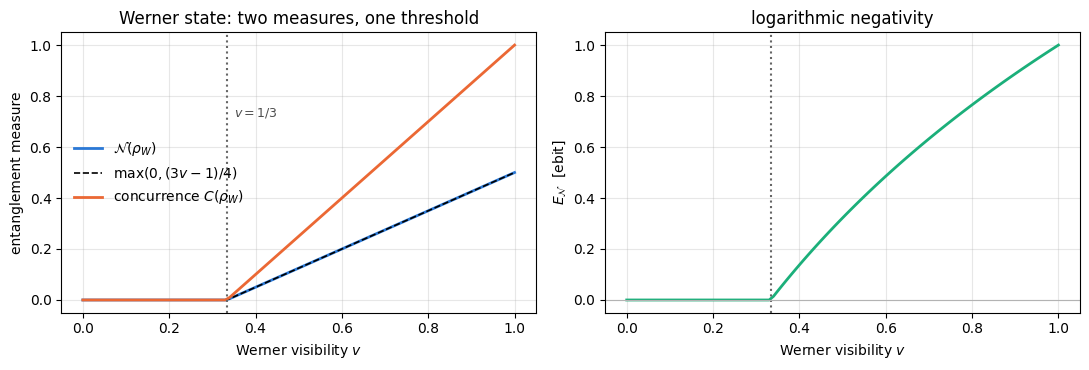

In [8]:
# ==============================================================================
# STEP 5: Werner states -- negativity, concurrence and the 1/3 threshold
# ==============================================================================
vs = np.linspace(0.0, 1.0, 101)
neg_v = np.array([neg_of_matrix(werner_matrix(float(v)), 1, 1)[0] for v in vs])
logneg_v = np.array([neg_of_matrix(werner_matrix(float(v)), 1, 1)[1] for v in vs])
conc_v = np.array([concurrence(werner_matrix(float(v))) for v in vs])
ana_v = np.maximum(0.0, (3 * vs - 1) / 4)

print(f"max |N(numeric) - (3v-1)/4| = {np.max(np.abs(neg_v - ana_v)):.3e}")
assert np.max(np.abs(neg_v - ana_v)) < 1e3 * TOL
i_first = int(np.argmax(neg_v > 1e-12))
print(f"first grid point with N > 0: v = {vs[i_first]:.3f}  (exact threshold 1/3 = {1/3:.3f})")
print(f"v = 1/3 exactly: N = {neg_of_matrix(werner_matrix(1/3), 1, 1)[0]:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(vs, neg_v, lw=2, label=r"$\mathcal{N}(\rho_W)$")
axes[0].plot(vs, ana_v, "--", lw=1.2, color="k", label=r"$\max(0,(3v-1)/4)$")
axes[0].plot(vs, conc_v, lw=2, color=PALETTE[1], label=r"concurrence $C(\rho_W)$")
axes[0].axvline(1 / 3, color="0.4", ls=":")
axes[0].text(0.35, 0.72, r"$v=1/3$", fontsize=9, color="0.3")
axes[0].set_xlabel(r"Werner visibility $v$"); axes[0].set_ylabel("entanglement measure")
axes[0].set_title("Werner state: two measures, one threshold"); axes[0].legend()

axes[1].plot(vs, logneg_v, lw=2, color=PALETTE[2])
axes[1].axvline(1 / 3, color="0.4", ls=":"); axes[1].axhline(0, color="0.7", lw=0.8)
axes[1].set_xlabel(r"Werner visibility $v$"); axes[1].set_ylabel(r"$E_{\mathcal{N}}$  [ebit]")
axes[1].set_title("logarithmic negativity")
fig.tight_layout(); plt.show()

The numerical negativity follows Eq. (7) to $10^{-16}$, and at $v=1/3$ it is zero to machine precision: the analytic threshold
and the diagonalisation agree. The concurrence of the Werner state, $C=\max(0,(3v-1)/2)$, is exactly twice the negativity
here, and it crosses zero at the same point — which is the next topic.

### 6.4 Negativity against concurrence for two qubits

For two qubits there is a second computable measure, Wootters' **concurrence** $C(\rho)$ (1998), from which the entanglement
of formation follows exactly. Negativity and concurrence are different functions of $\rho$, but they are tied together:
Verstraete, Audenaert, Dehaene and De Moor (2001) proved

$$\sqrt{(1-C)^2+C^2}-(1-C)\ \le\ 2\mathcal N\ \le\ C . \tag{8}$$

The upper bound is saturated by pure states. Indeed, for a pure two-qubit state with Schmidt coefficients
$\lambda_1,\lambda_2$ we will show in Section 7 that $\mathcal N=\lambda_1\lambda_2$, while Wootters' formula gives
$C=2\lambda_1\lambda_2$; hence $2\mathcal N=C$ exactly. The lower bound is reached as well, for example by the rank-2 family
$\rho_x=x\vert\Phi^+\rangle\langle\Phi^+\vert+(1-x)\vert01\rangle\langle01\vert$. Its partial transpose contains the block
$\begin{pmatrix}1-x&x/2\\x/2&0\end{pmatrix}$ on $\{\vert01\rangle,\vert10\rangle\}$, whose negative eigenvalue gives
$2\mathcal N=\sqrt{(1-x)^2+x^2}-(1-x)$, and Wootters' formula gives $C=x$. Inequality (8) says that for two qubits the two measures *order* states almost, but not
quite, in the same way: they agree on which states are entangled, and they can disagree on which of two states is more
entangled.

max (2N - C)            = +2.069e-08   (must be <= 0 up to the ~1e-8 accuracy of C)
min (2N - lower bound)  = +0.000e+00   (must be >= 0)
rank-1 (pure) states: max |2N - C| = 2.069e-08
restricted to C > 0.05 (333 states): min (2N - lower bound) = +0.0030   -> the lower edge of Eq. (8) is NOT probed by Hilbert-Schmidt-random states
edge family x|Phi+><Phi+| + (1-x)|01><01|: max |C - x| = 6.3e-09, max |2N - lower bound| = 8.2e-09
   control: the same family against the UPPER bound, min (C - 2N) = 0.0487


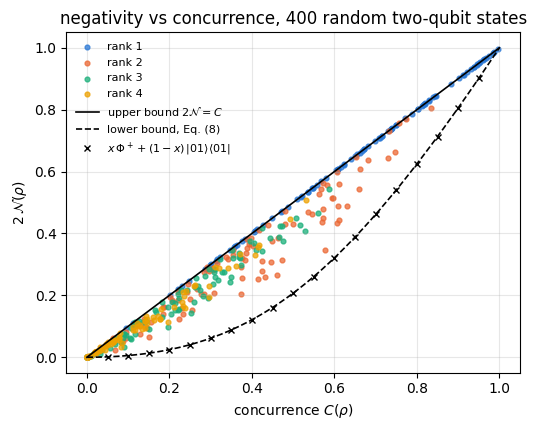

In [9]:
# ==============================================================================
# STEP 6: 2 N(rho) vs C(rho) over 400 random two-qubit states of every rank
# ==============================================================================
def random_mixed(key, d, rank):
    """Random density matrix of dimension d and given rank: G G^dagger / Tr, G a d x rank Ginibre matrix.
    (Rank 1 gives Haar-random pure states; rank d gives the Hilbert-Schmidt ensemble.)
    JAX: `rank` is a static Python int (it sets the array shape), `key` is traced -> vmap over keys."""
    k1, k2 = jax.random.split(key)
    G = jax.random.normal(k1, (d, rank)) + 1j * jax.random.normal(k2, (d, rank))
    r = G @ G.conj().T
    return r / jnp.trace(r)


def conc_and_neg(rho_mat):
    """(concurrence, negativity) of a 4x4 density matrix, written so that it can be vmapped:
    no Python float() conversions, no data-dependent branching."""
    YY_ = jnp.kron(Y, Y)
    rho_tilde = YY_ @ jnp.conj(rho_mat) @ YY_
    s = _sqrtm_psd(rho_mat)
    lam = jnp.sqrt(jnp.clip(jnp.linalg.eigvalsh(s @ rho_tilde @ s), 0.0, None))     # ascending
    C = jnp.maximum(0.0, lam[3] - lam[2] - lam[1] - lam[0])
    mu = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(dm_tensor(rho_mat, 2), [0])))
    return C, jnp.sum(jnp.abs(mu) - mu) / 2


# vmap over 100 PRNG keys for each rank: one batched call instead of 400 Python iterations
C_arr, N_arr, rank_arr = [], [], []
for rank in (1, 2, 3, 4):
    keys = jax.random.split(jax.random.PRNGKey(2024 + rank), 100)
    run = jax.jit(jax.vmap(lambda k: conc_and_neg(random_mixed(k, 4, rank))))
    c, n = run(keys)
    C_arr.append(np.asarray(c)); N_arr.append(np.asarray(n)); rank_arr.append(np.full(100, rank))
C_arr, N_arr, rank_arr = np.concatenate(C_arr), np.concatenate(N_arr), np.concatenate(rank_arr)

upper_violation = float(np.max(2 * N_arr - C_arr))
lower = np.sqrt((1 - C_arr) ** 2 + C_arr ** 2) - (1 - C_arr)
lower_violation = float(np.min(2 * N_arr - lower))
print(f"max (2N - C)            = {upper_violation:+.3e}   (must be <= 0 up to the ~1e-8 accuracy of C)")
print(f"min (2N - lower bound)  = {lower_violation:+.3e}   (must be >= 0)")
print(f"rank-1 (pure) states: max |2N - C| = {np.max(np.abs(2 * N_arr - C_arr)[rank_arr == 1]):.3e}")
# How much POWER do the two checks have?  The upper bound is saturated by the pure states, so the first
# line is a sharp test.  The lower bound is saturated only at C = 0, where both sides vanish; restricted
# to genuinely entangled states this ensemble never comes near it.
far = C_arr > 0.05
print(f"restricted to C > 0.05 ({far.sum()} states): min (2N - lower bound) = {np.min((2*N_arr - lower)[far]):+.4f}"
      f"   -> the lower edge of Eq. (8) is NOT probed by Hilbert-Schmidt-random states")
assert upper_violation < 1e3 * TOL and lower_violation > -1e3 * TOL
# The pure-state EQUALITY 2N = C is what can catch a factor-2 convention error (N/2 or 2N in place of N
# would still satisfy "2N <= C" on one side), so it is asserted separately.
assert np.max(np.abs(2 * N_arr - C_arr)[rank_arr == 1]) < 1e-6


# The lower edge, probed with a family that sits ON it:  rho_x = x |Phi+><Phi+| + (1-x) |01><01|.
# Its partial transpose has the 2x2 block [[1-x, x/2], [x/2, 0]] on {|01>,|10>}, so
# 2N = sqrt((1-x)^2 + x^2) - (1-x), and its concurrence is C = x: the lower bound of Eq. (8) with equality.
def edge_state(x):
    e01 = jnp.zeros(4, dtype=CDTYPE).at[1].set(1.0)
    return werner_matrix(1.0) * x + (1 - x) * jnp.outer(e01, e01)


xs_edge = np.linspace(0.05, 0.95, 19)
C_edge = np.array([concurrence(edge_state(float(x))) for x in xs_edge])
N_edge = np.array([neg_of_matrix(edge_state(float(x)), 1, 1)[0] for x in xs_edge])
gap_edge = np.max(np.abs(2 * N_edge - (np.sqrt((1 - C_edge) ** 2 + C_edge ** 2) - (1 - C_edge))))
print(f"edge family x|Phi+><Phi+| + (1-x)|01><01|: max |C - x| = {np.max(np.abs(C_edge - xs_edge)):.1e}, "
      f"max |2N - lower bound| = {gap_edge:.1e}")
print(f"   control: the same family against the UPPER bound, min (C - 2N) = {np.min(C_edge - 2 * N_edge):.4f}")
assert np.max(np.abs(C_edge - xs_edge)) < 1e-6 and gap_edge < 1e-6 and np.min(C_edge - 2 * N_edge) > 0.01

fig, ax = plt.subplots(figsize=(5.4, 4.4))
for r in (1, 2, 3, 4):
    m = rank_arr == r
    ax.scatter(C_arr[m], 2 * N_arr[m], s=12, alpha=0.75, label=f"rank {r}")
cc = np.linspace(0, 1, 200)
ax.plot(cc, cc, "k-", lw=1.2, label=r"upper bound $2\mathcal{N}=C$")
ax.plot(cc, np.sqrt((1 - cc) ** 2 + cc ** 2) - (1 - cc), "k--", lw=1.2, label="lower bound, Eq. (8)")
ax.plot(C_edge, 2 * N_edge, "kx", ms=5, label=r"$x\,\Phi^+ + (1-x)\,\vert 01\rangle\langle 01\vert$")
ax.set_xlabel(r"concurrence $C(\rho)$"); ax.set_ylabel(r"$2\,\mathcal{N}(\rho)$")
ax.set_title("negativity vs concurrence, 400 random two-qubit states")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

All 400 states lie inside the band of Eq. (8); the rank-1 (pure) states lie exactly on the upper edge $2\mathcal N=C$, to
$10^{-8}$, which is the accuracy of the concurrence at $C$ close to $0$ (it involves square roots of eigenvalues that are
themselves close to zero, so the tiny positive value printed on the first line is that roundoff and not a violation). The
higher the rank, the further a state can fall below the diagonal: mixing degrades the negativity faster than it degrades the
concurrence.

The random sample does not test the two bounds equally well. The upper bound is *saturated* by the pure states, and the
cell asserts the equality $\vert2\mathcal N-C\vert<10^{-6}$ on the rank-1 states separately. That separate assert matters:
a factor-2 error in the convention, writing $\mathcal N$ where $2\mathcal N$ belongs, would still pass "$2\mathcal N\le C$"
and would only show up as a gap of $\tfrac12C$ on the rank-1 line. In the random sample the lower bound is approached only
at $C=0$, where both sides vanish; restricted to $C>0.05$ the closest approach is $0.003$ above the dashed curve.
Hilbert–Schmidt-random states do not populate the lower edge. The crosses are the family $\rho_x$ derived above, which sits
on the edge to $10^{-8}$ (the accuracy of $C$). The same family misses the upper bound by more than $0.01$ for every $x$
in the scan, so the check can tell the two edges apart.

> **Common pitfall.** The band in Eq. (8) has finite width, so "negativity $A$ > negativity $B$" does **not** imply
> "concurrence $A$ > concurrence $B$". Different entanglement measures induce different orderings of mixed states; they agree
> only on the boundary (zero or maximal entanglement) and on pure states. Whenever you compare two states, say which measure
> you used.

## 7. Pure states: negativity from the Schmidt coefficients

### 7.1 The derivation

For a pure state the partial transpose can be diagonalised in closed form. Start from the Schmidt decomposition across the cut
$A\vert B$ (see [notebook 06](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)),

$$\vert\psi\rangle=\sum_{k}\lambda_k\,\vert a_k\rangle_A\vert b_k\rangle_B ,\qquad \lambda_k\ge0,\quad\sum_k\lambda_k^2=1 ,$$

with $\{\vert a_k\rangle\}$ and $\{\vert b_k\rangle\}$ orthonormal. Then

$$\rho=\vert\psi\rangle\langle\psi\vert=\sum_{k,l}\lambda_k\lambda_l\,\vert a_k\rangle\langle a_l\vert\otimes
  \vert b_k\rangle\langle b_l\vert ,$$

and the partial transpose on $A$ flips $\vert a_k\rangle\langle a_l\vert\to\vert a_l\rangle\langle a_k\vert$:

$$\rho^{T_A}=\sum_{k,l}\lambda_k\lambda_l\,\vert a_l\rangle\langle a_k\vert\otimes\vert b_k\rangle\langle b_l\vert . \tag{9}$$

Now read off the eigenvectors of Eq. (9) directly.

* **Diagonal terms $k=l$.** The vector $\vert a_k\rangle\vert b_k\rangle$ is mapped to $\lambda_k^2\vert a_k\rangle\vert
  b_k\rangle$ (only the $k=l$ term of the sum contributes, because $\langle a_k\vert a_l\rangle=\delta_{kl}$ and
  $\langle b_l\vert b_k\rangle=\delta_{kl}$). Eigenvalue $\lambda_k^2$, one for each $k$.
* **Off-diagonal pairs $k\ne l$.** The two-dimensional space spanned by $\vert a_k\rangle\vert b_l\rangle$ and
  $\vert a_l\rangle\vert b_k\rangle$ is left invariant: Eq. (9) maps
  $\vert a_k\rangle\vert b_l\rangle\mapsto\lambda_k\lambda_l\,\vert a_l\rangle\vert b_k\rangle$ and vice versa. On that
  two-dimensional space the matrix is $\lambda_k\lambda_l\begin{pmatrix}0&1\\1&0\end{pmatrix}$, whose eigenvalues are
  $\pm\lambda_k\lambda_l$ with eigenvectors $(\vert a_k\rangle\vert b_l\rangle\pm\vert a_l\rangle\vert b_k\rangle)/\sqrt2$.

Every vector of the product basis $\{\vert a_k\rangle\vert b_l\rangle\}$ is accounted for, so this is the complete spectrum:

$$\mathrm{spec}\,\rho^{T_A}=\{\lambda_k^2\}_{k}\ \cup\ \{\pm\lambda_k\lambda_l\}_{k<l} . \tag{10}$$

Summing absolute values,

$$\lVert\rho^{T_A}\rVert_1=\sum_k\lambda_k^2+2\sum_{k<l}\lambda_k\lambda_l=\Bigl(\sum_k\lambda_k\Bigr)^2 ,$$

which is the square of the $\ell^1$ norm of the Schmidt vector. Therefore

$$\boxed{\ \mathcal N(\psi)=\frac{\bigl(\sum_k\lambda_k\bigr)^2-1}{2},\qquad
  E_{\mathcal N}(\psi)=2\log_2\sum_k\lambda_k .\ } \tag{11}$$

Two immediate consequences. For a product state only one $\lambda$ is non-zero and equals $1$, so $\mathcal N=0$. For two
qubits, $\lambda_1^2+\lambda_2^2=1$ gives $(\lambda_1+\lambda_2)^2=1+2\lambda_1\lambda_2$ and hence
$\mathcal N=\lambda_1\lambda_2$, the formula used in Section 6.4.

### 7.2 The logarithmic negativity is a Renyi entropy of index $1/2$

The Renyi entropies of the reduced state are $S_\alpha=\frac{1}{1-\alpha}\log_2\mathrm{Tr}\,\rho_A^\alpha$, and the
eigenvalues of $\rho_A$ are $p_k=\lambda_k^2$. At $\alpha=1/2$,

$$S_{1/2}=\frac{1}{1-\tfrac12}\log_2\sum_kp_k^{1/2}=2\log_2\sum_k\lambda_k ,$$

which is exactly $E_{\mathcal N}$ from Eq. (11):

$$E_{\mathcal N}(\psi)=S_{1/2}(\rho_A) . \tag{12}$$

For a pure state, then, the logarithmic negativity is not a new quantity at all: it is a member of the Renyi family that we
already know, sitting at index $1/2$. Since $S_\alpha$ decreases with $\alpha$, Eq. (12) gives
$E_{\mathcal N}\ge S_1=S$, the von Neumann entanglement entropy: the logarithmic negativity *over*estimates the distillable
entanglement of a pure state, consistent with it being an upper bound on $E_D$, which for pure states equals $S$.

### 7.3 Implementation and validation

Eq. (11) replaces an eigenvalue problem of size $2^N$ by a singular value decomposition of a $2^{\vert A\vert}\times
2^{\vert B\vert}$ matrix, which the engine already provides as `schmidt_values`. We implement it, then check it against the
brute-force partial transpose on the zoo of states.

In [10]:
# ==============================================================================
# STEP 7: pure-state negativity from the Schmidt coefficients
# ==============================================================================
def negativity_pure(psi, subsystem):
    """Negativity of a PURE state across the cut A = `subsystem`, from its Schmidt coefficients.

    MATH   N = ( (sum_k lambda_k)^2 - 1 ) / 2 ,   E_N = 2 log2 sum_k lambda_k = S_{1/2}(rho_A)   [Eq. (11)]
    IMPLEMENTATION  `schmidt_values` transposes the A axes to the front, reshapes to a matrix and takes its
           singular values -- the density matrix is never formed.
    COST   O(2^N) memory, O(2^{|A|} 2^N) for the SVD, against O(4^N) memory and O(8^N) time for the
           brute-force partial transpose.  Measured in Section 11: the brute-force route needs about 40 s
           (one thread) at N = 12, the SVD route is limited only by the 2^N state vector.
    """
    lam = schmidt_values(psi, subsystem)
    s = jnp.sum(lam)
    return (s ** 2 - 1) / 2, 2 * jnp.log2(s)


def negativity_pure_bruteforce(psi, subsystem):
    """The same number the expensive way: build |psi><psi| as a rank-2N tensor and diagonalise its partial
    transpose.  Used ONLY to validate `negativity_pure` on small systems."""
    return negativity(to_dm(psi), subsystem)


N_small = 8
psi_cluster = product_state("+" * N_small)           # 1D cluster state: |+>^N followed by CZ on every bond
for q in range(N_small - 1):
    psi_cluster = apply_gate(psi_cluster, CZ, [q, q + 1])

zoo = {"GHZ": ghz_state(N_small),
       "W": w_state(N_small),
       "Dicke k=N/2": dicke_state(N_small, N_small // 2),
       "cluster": psi_cluster,
       "Haar random": haar_state(jax.random.PRNGKey(11), N_small)}

print(f"N = {N_small}; cut A = first k qubits\n")
print(f"{'state':>13s} {'k':>2s} {'N (Schmidt)':>12s} {'N (brute PT)':>13s} {'difference':>11s} "
      f"{'E_N':>8s} {'S_1/2':>8s} {'S (von Neumann)':>16s}")
worst = 0.0
for name, psi in zoo.items():
    for k in (1, N_small // 2):
        A = tuple(range(k))
        n_s, e_s = negativity_pure(psi, A)
        n_b, e_b = negativity_pure_bruteforce(psi, A)
        p = jnp.clip(schmidt_values(psi, A) ** 2, 1e-16, None)
        S_half = float(2 * jnp.log2(jnp.sum(jnp.sqrt(p))))
        S_vn = float(entanglement_entropy(psi, A))
        worst = max(worst, abs(float(n_s) - float(n_b)))
        print(f"{name:>13s} {k:2d} {float(n_s):12.8f} {float(n_b):13.8f} {abs(float(n_s)-float(n_b)):11.2e} "
              f"{float(e_s):8.4f} {S_half:8.4f} {S_vn:16.4f}")
print(f"\nlargest Schmidt-vs-brute-force discrepancy: {worst:.2e}")
assert worst < 1e3 * TOL

N = 8; cut A = first k qubits

        state  k  N (Schmidt)  N (brute PT)  difference      E_N    S_1/2  S (von Neumann)


          GHZ  1   0.50000000    0.50000000    1.11e-16   1.0000   1.0000           1.0000
          GHZ  4   0.50000000    0.50000000    1.11e-16   1.0000   1.0000           1.0000
            W  1   0.33071891    0.33071891    1.17e-15   0.7324   0.7324           0.5436
            W  4   0.50000000    0.50000000    2.22e-16   1.0000   1.0000           1.0000
  Dicke k=N/2  1   0.50000000    0.50000000    2.00e-15   1.0000   1.0000           1.0000


  Dicke k=N/2  4   1.32857143    1.32857143    1.78e-15   1.8707   1.8707           1.6419
      cluster  1   0.50000000    0.50000000    4.44e-15   1.0000   1.0000           1.0000
      cluster  4   0.50000000    0.50000000    4.66e-15   1.0000   1.0000           1.0000
  Haar random  1   0.49887781    0.49887781    2.83e-15   0.9984   0.9984           0.9968
  Haar random  4   5.34817104    5.34817104    8.88e-16   3.5480   3.5480           3.3144

largest Schmidt-vs-brute-force discrepancy: 4.66e-15


The two routes agree to a few $10^{-15}$ on every state and every cut, the column $E_{\mathcal N}$ reproduces $S_{1/2}$ digit for
digit (Eq. (12)), and $E_{\mathcal N}\ge S$ holds everywhere, with equality only where the Schmidt spectrum is flat — the GHZ
state, whose two Schmidt values are both $1/\sqrt2$, has $E_{\mathcal N}=S=1$ ebit at every cut.

### 7.4 Analytic values for GHZ, W and Dicke states

Eq. (11) turns the standard states into closed formulas. Split $N$ qubits into $A$ = the first $k$ and $B$ = the rest.

* **GHZ.** $\vert\mathrm{GHZ}\rangle=\tfrac{1}{\sqrt2}(\vert0^N\rangle+\vert1^N\rangle)
  =\tfrac{1}{\sqrt2}\vert0^k\rangle\vert0^{N-k}\rangle+\tfrac{1}{\sqrt2}\vert1^k\rangle\vert1^{N-k}\rangle$ is already in
  Schmidt form with $\lambda_1=\lambda_2=1/\sqrt2$ for every $k$. Hence $(\sum\lambda)^2=2$ and

  $$\mathcal N_{\mathrm{GHZ}}=\tfrac12,\qquad E_{\mathcal N}=1\ \text{ebit, for every }k=1,\dots,N-1 .$$

* **W.** $\vert W_N\rangle=\tfrac{1}{\sqrt N}\sum_i\vert0\cdots1_i\cdots0\rangle$. The $k$ terms whose excitation sits in $A$
  give $\sqrt{k/N}\,\vert W_k\rangle_A\vert0^{N-k}\rangle_B$, the other $N-k$ give
  $\sqrt{(N-k)/N}\,\vert0^k\rangle_A\vert W_{N-k}\rangle_B$; the two are already orthonormal, so the Schmidt values are
  $\sqrt{k/N}$ and $\sqrt{(N-k)/N}$ and

  $$\mathcal N_{W}(k)=\frac{\bigl(\sqrt{k/N}+\sqrt{(N-k)/N}\bigr)^2-1}{2}=\frac{\sqrt{k(N-k)}}{N} .$$

* **Dicke.** For $\vert D_N^m\rangle$ (all states with $m$ excitations, equally weighted) the cut sorts the basis states by
  the number $j$ of excitations in $A$, giving
  $\lambda_j=\sqrt{\binom{k}{j}\binom{N-k}{m-j}/\binom{N}{m}}$ (hypergeometric weights), and $\mathcal N$ follows from
  Eq. (11). The Schmidt rank is now $\min(k,m)+1$ terms rather than $2$, which is why Dicke states are far more entangled
  than W states.

The next cell checks the first two formulas and plots all four profiles at $N=10$.

 k        GHZ   analytic          W   analytic      Dicke   analytic     random
 1   0.500000   0.500000   0.300000   0.300000   0.500000   0.500000     0.4990
 2   0.500000   0.500000   0.400000   0.400000   0.924951   0.924951     1.4925
 3   0.500000   0.500000   0.458258   0.458258   1.245356   1.245356     3.4332
 4   0.500000   0.500000   0.489898   0.489898   1.449468   1.449468     6.9793
 5   0.500000   0.500000   0.500000   0.500000   1.531746   1.531746    11.1631
 6   0.500000   0.500000   0.489898   0.489898   1.449468   1.449468     7.0059
 7   0.500000   0.500000   0.458258   0.458258   1.245356   1.245356     3.4302
 8   0.500000   0.500000   0.400000   0.400000   0.924951   0.924951     1.4930
 9   0.500000   0.500000   0.300000   0.300000   0.500000   0.500000     0.4989

largest deviation from the analytic formulas: 1.33e-15


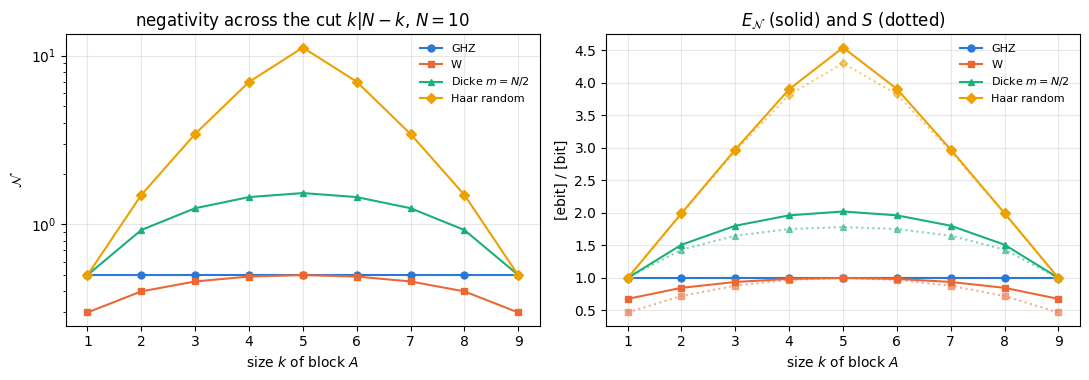

In [11]:
# ==============================================================================
# STEP 8: negativity profile across every cut, N = 10
# ==============================================================================
from math import comb

N_zoo = 10
ks = np.arange(1, N_zoo)
psi_ghz, psi_w = ghz_state(N_zoo), w_state(N_zoo)
psi_dicke = dicke_state(N_zoo, N_zoo // 2)
psi_rand = haar_state(jax.random.PRNGKey(3), N_zoo)

neg_ghz = np.array([float(negativity_pure(psi_ghz, tuple(range(k)))[0]) for k in ks])
neg_w = np.array([float(negativity_pure(psi_w, tuple(range(k)))[0]) for k in ks])
neg_dicke = np.array([float(negativity_pure(psi_dicke, tuple(range(k)))[0]) for k in ks])
neg_rand = np.array([float(negativity_pure(psi_rand, tuple(range(k)))[0]) for k in ks])

ana_ghz = np.full_like(ks, 0.5, dtype=float)
ana_w = np.sqrt(ks * (N_zoo - ks)) / N_zoo
m = N_zoo // 2
ana_dicke = np.array([((sum(np.sqrt(comb(k, j) * comb(N_zoo - k, m - j) / comb(N_zoo, m))
                            for j in range(max(0, m - (N_zoo - k)), min(k, m) + 1))) ** 2 - 1) / 2 for k in ks])

print(f"{'k':>2s} {'GHZ':>10s} {'analytic':>10s} {'W':>10s} {'analytic':>10s} "
      f"{'Dicke':>10s} {'analytic':>10s} {'random':>10s}")
for i, k in enumerate(ks):
    print(f"{k:2d} {neg_ghz[i]:10.6f} {ana_ghz[i]:10.6f} {neg_w[i]:10.6f} {ana_w[i]:10.6f} "
          f"{neg_dicke[i]:10.6f} {ana_dicke[i]:10.6f} {neg_rand[i]:10.4f}")
err = max(np.max(np.abs(neg_ghz - ana_ghz)), np.max(np.abs(neg_w - ana_w)), np.max(np.abs(neg_dicke - ana_dicke)))
print(f"\nlargest deviation from the analytic formulas: {err:.2e}")
assert err < 1e3 * TOL

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for lbl, y, mk in [("GHZ", neg_ghz, "o"), ("W", neg_w, "s"), (r"Dicke $m=N/2$", neg_dicke, "^"),
                   ("Haar random", neg_rand, "D")]:
    axes[0].plot(ks, y, mk + "-", ms=5, label=lbl)
axes[0].set_yscale("log"); axes[0].set_xlabel(r"size $k$ of block $A$")
axes[0].set_ylabel(r"$\mathcal{N}$"); axes[0].set_title(rf"negativity across the cut $k\vert N-k$, $N={N_zoo}$")
axes[0].legend(fontsize=8)

for j, (lbl, psi, mk) in enumerate([("GHZ", psi_ghz, "o"), ("W", psi_w, "s"),
                                    (r"Dicke $m=N/2$", psi_dicke, "^"), ("Haar random", psi_rand, "D")]):
    e_n = [float(negativity_pure(psi, tuple(range(k)))[1]) for k in ks]
    s_vn = [float(entanglement_entropy(psi, tuple(range(k)))) for k in ks]
    axes[1].plot(ks, e_n, mk + "-", ms=5, color=PALETTE[j], label=lbl)
    axes[1].plot(ks, s_vn, mk + ":", ms=4, color=PALETTE[j], alpha=0.55)
axes[1].set_xlabel(r"size $k$ of block $A$"); axes[1].set_ylabel(r"[ebit] / [bit]")
axes[1].set_title(r"$E_{\mathcal{N}}$ (solid) and $S$ (dotted)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

All three analytic formulas are reproduced to $10^{-15}$. The four profiles say four different things:

* **GHZ** is flat at $\mathcal N=1/2$: one ebit across every cut, no matter how the chain is divided. All of its entanglement
  is a single two-dimensional degree of freedom shared by all qubits at once.
* **W** peaks in the middle at $\mathcal N=1/2$ and falls to $3/10$ at $k=1$, following $\sqrt{k(N-k)}/N$.
* **Dicke** with $m=N/2$ reaches $\mathcal N=1.53$ at the half cut, three times the GHZ value, because its Schmidt rank grows
  with the block size instead of staying at $2$.
* The **Haar-random** state reaches $\mathcal N=11.16$ at the half cut, growing roughly by a factor of two for every spin
  added to the smaller block ($0.499$, $1.49$, $3.43$, $6.98$, $11.16$ for $k=1,\dots,5$). For $k\ll N/2$ this is what
  Eq. (11) gives for a nearly maximally mixed $\rho_A$: all $2^k$ Schmidt values close to $2^{-k/2}$, so
  $\sum_k\lambda_k\approx2^{k/2}$ and $\mathcal N\approx(2^k-1)/2=0.5,\ 1.5,\ 3.5,\ 7.5$. The estimate overshoots at
  $k=4$ ($7.5$ against $6.98$) because $\rho_A$ is then no longer close to maximally mixed. Exponential growth with
  $\min(k,N-k)$ is the signature of volume-law entanglement. On the right panel $E_{\mathcal N}$ (solid) lies above $S$
  (dotted) for every state and every cut, as Eq. (12) requires; in the $N=8$ table above, the half cut of the random state
  gives $E_{\mathcal N}=3.5480$ ebit against $S=3.3144$ bit, while for GHZ the two coincide at $1$ because its Schmidt
  spectrum is flat.

## 8. Mixed states: entropy can grow while entanglement dies

Section 3 showed that $S(\rho_A)$ cannot detect entanglement in a mixed state. The following experiment shows something
sharper: along a physical decoherence path, the *global* entropy of a two-qubit state increases monotonically while the
negativity reaches exactly zero at a finite noise strength and stays there. The two quantities are not merely different — they
are not even monotone functions of each other.

Take a Bell pair and apply an independent depolarising channel of strength $p$ to each qubit. A single depolarising channel
shrinks the Bloch vector by $\eta=1-\tfrac43p$ (derived in
[notebook 07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)); applying it to both halves of
$\vert\Phi^+\rangle$ produces exactly the Werner state of Eq. (6) with

$$v=\eta^2=\Bigl(1-\tfrac43p\Bigr)^2 ,$$

because the two-qubit correlators $\langle XX\rangle,\langle YY\rangle,\langle ZZ\rangle$ each pick up one factor $\eta$ per
qubit. Eq. (7) then predicts $\mathcal N=\max(0,(3\eta^2-1)/4)$ and a death at $\eta^2=1/3$, that is

$$p_{\rm death}=\frac34\left(1-\frac{1}{\sqrt3}\right)=0.316987\ldots \tag{13}$$

The next cell measures the negativity, the concurrence, the global entropy and the subsystem entropy along the same path.

max |N(numeric) - (3 eta^2 - 1)/4| = 2.776e-16
measured death on this grid: p = 0.3200   (grid spacing 0.0050)
Eq. (13):                    p = 0.316987
S(rho) at the death point   = 1.7924 bit   (of 2 bit maximum)
S(rho) at p = 0.75          = 2.0000 bit
S(rho_A) is constant:  min = 1.000000, max = 1.000000 bit


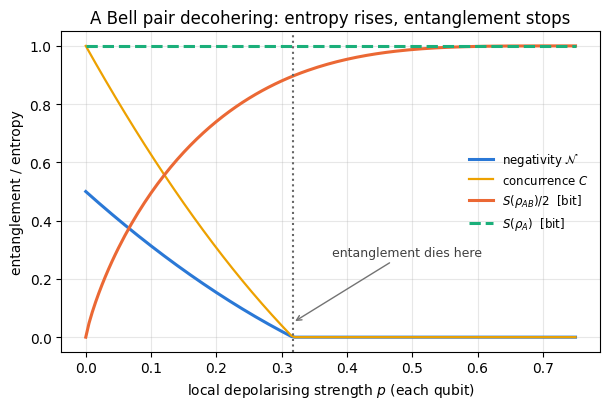

In [12]:
# ==============================================================================
# STEP 9: a Bell pair under local depolarising noise -- negativity, S(rho), S(rho_A)
# ==============================================================================
ps = np.linspace(0.0, 0.75, 151)
rows = []
for p in ps:
    r = to_dm(bell_state("phi+"))
    for q in (0, 1):
        r = apply_kraus_dm(r, kraus_depolarizing(float(p)), [q])
    rows.append((float(negativity(r, [0])[0]),
                 float(von_neumann_entropy(dm_matrix(r))),
                 float(von_neumann_entropy(rdm_dm(r, [0]))),
                 float(concurrence(dm_matrix(r)))))
neg_p, S_glob, S_sub, conc_p = map(np.array, zip(*rows))

eta = 1 - 4 * ps / 3
ana = np.maximum(0.0, (3 * eta ** 2 - 1) / 4)
print(f"max |N(numeric) - (3 eta^2 - 1)/4| = {np.max(np.abs(neg_p - ana)):.3e}")
assert np.max(np.abs(neg_p - ana)) < 1e3 * TOL
p_death_meas = ps[int(np.argmax(neg_p <= 1e-12))]
p_death_exact = 0.75 * (1 - 1 / np.sqrt(3))
print(f"measured death on this grid: p = {p_death_meas:.4f}   (grid spacing {ps[1]-ps[0]:.4f})")
print(f"Eq. (13):                    p = {p_death_exact:.6f}")
print(f"S(rho) at the death point   = {np.interp(p_death_exact, ps, S_glob):.4f} bit   (of 2 bit maximum)")
print(f"S(rho) at p = 0.75          = {S_glob[-1]:.4f} bit")
print(f"S(rho_A) is constant:  min = {S_sub.min():.6f}, max = {S_sub.max():.6f} bit")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(ps, neg_p, lw=2.2, label=r"negativity $\mathcal{N}$")
ax.plot(ps, conc_p, lw=1.6, color=PALETTE[3], label=r"concurrence $C$")
ax.plot(ps, S_glob / 2, lw=2.2, color=PALETTE[1], label=r"$S(\rho_{AB})/2$  [bit]")
ax.plot(ps, S_sub, lw=2.2, color=PALETTE[2], ls="--", label=r"$S(\rho_A)$  [bit]")
ax.axvline(p_death_exact, color="0.4", ls=":")
ax.annotate("entanglement dies here", xy=(p_death_exact, 0.05), xytext=(p_death_exact + 0.06, 0.28),
            fontsize=9, color="0.25", arrowprops=dict(arrowstyle="->", color="0.45"))
ax.set_xlabel(r"local depolarising strength $p$ (each qubit)")
ax.set_ylabel("entanglement / entropy")
ax.set_title("A Bell pair decohering: entropy rises, entanglement stops")
ax.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

The measured negativity follows Eq. (7) with $v=\eta^2$ to $10^{-16}$, and the first grid point at which it vanishes is
$p=0.3200$, consistent with the exact $0.316987$ given the grid spacing of $0.005$. At that point the global entropy is
$1.7924$ bit out of a maximum of $2$ bit and still climbing, and the subsystem entropy has not moved at all: $S(\rho_A)=1$ bit
for every $p$, because a depolarising channel maps the already-maximally-mixed $\rho_A=\mathbb 1/2$ to itself. Three curves,
three completely different verdicts about "how quantum" the state is.

### 8.1 Noisy GHZ states across every bipartition

The same contrast at $N$ qubits, with two different noise models.

**Global (isotropic) noise.** $\rho=(1-p)\vert\mathrm{GHZ}\rangle\langle\mathrm{GHZ}\vert+p\,\mathbb 1/2^N$. Because
$(\mathbb 1/2^N)^{T_A}=\mathbb 1/2^N$ and the GHZ partial transpose has eigenvalues $\pm\tfrac12$ (three $+$, one $-$) inside a
four-dimensional subspace and $0$ elsewhere, linearity gives a single negative eigenvalue $-\tfrac{1-p}{2}+\tfrac{p}{2^N}$ and

$$\mathcal N=\max\left(0,\ \frac{1-p}{2}-\frac{p}{2^N}\right),\qquad
  p_{\rm death}=\frac{2^{N-1}}{1+2^{N-1}} , \tag{14}$$

**independent of the cut $k$.**

**Local dephasing.** Applying $\rho\to(1-p)\rho+pZ\rho Z$ to every qubit multiplies the single coherence
$\rho_{0\ldots0,1\ldots1}$ by $(1-2p)$ per qubit and leaves the two populations alone, so the state stays in the
$\{\vert0^N\rangle,\vert1^N\rangle\}$ subspace with coherence $\tfrac12(1-2p)^N$ and

$$\mathcal N=\tfrac12(1-2p)^N , \tag{15}$$

again independent of the cut, and vanishing only at $p=1/2$.

GLOBAL depolarising (white noise):  N(k) for k = 1..N-1, and Eq. (14)


  p = 0.00: 0.500000 0.500000 0.500000 0.500000 0.500000   analytic 0.500000
  p = 0.30: 0.345312 0.345312 0.345312 0.345312 0.345312   analytic 0.345312
  p = 0.60: 0.190625 0.190625 0.190625 0.190625 0.190625   analytic 0.190625
  p = 0.90: 0.035937 0.035937 0.035937 0.035937 0.035937   analytic 0.035937
  p = 0.98: 0.000000 0.000000 0.000000 0.000000 0.000000   analytic 0.000000
  death at p = 2^(N-1)/(1+2^(N-1)) = 0.969697

LOCAL dephasing:  N(k) for k = 1..N-1, and Eq. (15)


  p = 0.00: 0.500000 0.500000 0.500000 0.500000 0.500000   analytic 0.500000
  p = 0.05: 0.265720 0.265720 0.265720 0.265720 0.265720   analytic 0.265721
  p = 0.10: 0.131072 0.131072 0.131072 0.131072 0.131072   analytic 0.131072
  p = 0.20: 0.023328 0.023328 0.023328 0.023328 0.023328   analytic 0.023328
  p = 0.40: 0.000032 0.000032 0.000032 0.000032 0.000032   analytic 0.000032

largest deviation from Eqs. (14)-(15) : 4.44e-16
largest spread over the cut k         : 0.00e+00   (Eqs. (14)-(15) claim independence of k)


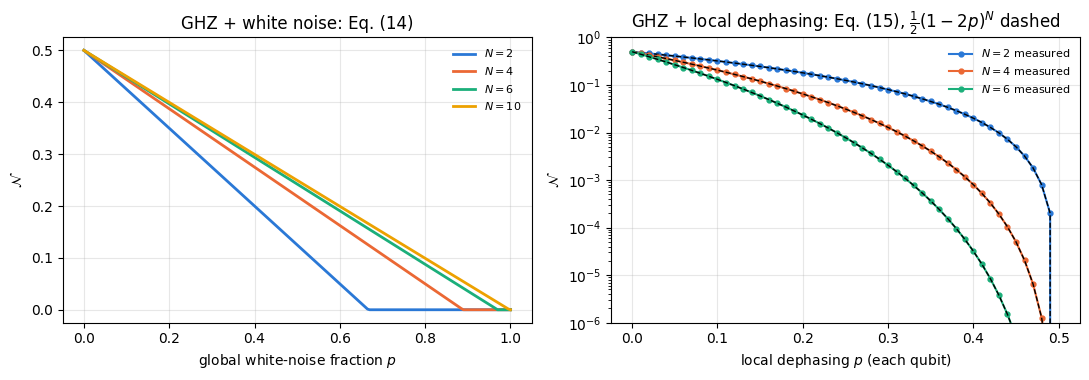

In [13]:
# ==============================================================================
# STEP 10: noisy GHZ, all bipartitions, two noise models
# ==============================================================================
N_ghz = 6
rho_pure_ghz = to_dm(ghz_state(N_ghz))
eye_t = jnp.eye(2 ** N_ghz, dtype=CDTYPE).reshape((2,) * (2 * N_ghz)) / 2 ** N_ghz

worst_formula, worst_cut = 0.0, 0.0            # accumulated so that the two claims can be ASSERTED, not just printed
print("GLOBAL depolarising (white noise):  N(k) for k = 1..N-1, and Eq. (14)")
for p in (0.0, 0.3, 0.6, 0.9, 0.98):
    rho = (1 - p) * rho_pure_ghz + p * eye_t
    vals = [float(negativity(rho, list(range(k)))[0]) for k in range(1, N_ghz)]
    ana = max(0.0, (1 - p) / 2 - p / 2 ** N_ghz)
    worst_formula = max(worst_formula, max(abs(v - ana) for v in vals))
    worst_cut = max(worst_cut, max(vals) - min(vals))
    print(f"  p = {p:4.2f}: " + " ".join(f"{v:.6f}" for v in vals) + f"   analytic {ana:.6f}")
print(f"  death at p = 2^(N-1)/(1+2^(N-1)) = {2**(N_ghz-1)/(1+2**(N_ghz-1)):.6f}")

print("\nLOCAL dephasing:  N(k) for k = 1..N-1, and Eq. (15)")
for p in (0.0, 0.05, 0.1, 0.2, 0.4):
    rho = rho_pure_ghz
    for q in range(N_ghz):
        rho = apply_kraus_dm(rho, kraus_dephasing(float(p)), [q])
    vals = [float(negativity(rho, list(range(k)))[0]) for k in range(1, N_ghz)]
    ana = 0.5 * (1 - 2 * p) ** N_ghz
    worst_formula = max(worst_formula, max(abs(v - ana) for v in vals))
    worst_cut = max(worst_cut, max(vals) - min(vals))
    print(f"  p = {p:4.2f}: " + " ".join(f"{v:.6f}" for v in vals) + f"   analytic {ana:.6f}")

print(f"\nlargest deviation from Eqs. (14)-(15) : {worst_formula:.2e}")
print(f"largest spread over the cut k         : {worst_cut:.2e}   (Eqs. (14)-(15) claim independence of k)")
assert worst_formula < 1e3 * TOL and worst_cut < 1e3 * TOL

# a scan for the figure, plus the system-size dependence of the local-dephasing decay
pp = np.linspace(0, 0.5, 51)
curves = {}
for Nq in (2, 4, 6):
    yy = []
    for p in pp:
        rho = to_dm(ghz_state(Nq))
        for q in range(Nq):
            rho = apply_kraus_dm(rho, kraus_dephasing(float(p)), [q])
        yy.append(float(negativity(rho, [0])[0]))
    curves[Nq] = np.array(yy)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
pg = np.linspace(0, 1, 201)
for Nq in (2, 4, 6, 10):
    axes[0].plot(pg, np.maximum(0, (1 - pg) / 2 - pg / 2 ** Nq), lw=2, label=f"$N={Nq}$")
axes[0].set_xlabel(r"global white-noise fraction $p$"); axes[0].set_ylabel(r"$\mathcal{N}$")
axes[0].set_title("GHZ + white noise: Eq. (14)"); axes[0].legend(fontsize=8)
for Nq, y in curves.items():
    axes[1].plot(pp, y, "o-", ms=3.5, label=f"$N={Nq}$ measured")
    axes[1].plot(pp, 0.5 * (1 - 2 * pp) ** Nq, "k--", lw=1)
axes[1].set_yscale("log"); axes[1].set_ylim(1e-6, 1)
axes[1].set_xlabel(r"local dephasing $p$ (each qubit)"); axes[1].set_ylabel(r"$\mathcal{N}$")
axes[1].set_title(r"GHZ + local dephasing: Eq. (15), $\frac{1}{2}(1-2p)^N$ dashed"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Both formulas are confirmed to $10^{-16}$, and the spread of the negativity over the cut $k$ is of the same size, so both
quantities really are independent of where the chain is cut — an unusual feature that comes from the GHZ state having Schmidt
rank $2$ across every cut, so that the noisy state never leaves a four-dimensional effective problem.

The two noise models could hardly behave more differently. *Global* white noise is extremely forgiving: at $N=6$ the
negativity survives until $p=0.9697$, and the threshold $2^{N-1}/(1+2^{N-1})$ tends to $1$ as the system grows, because the
maximally mixed state is spread over $2^N$ levels and each of them carries only $p/2^N$. *Local* dephasing is the opposite:
each qubit multiplies the surviving coherence by $(1-2p)$, so the negativity decays as the $N$-th power. At $p=0.1$ the
table gives $\mathcal N=0.1311$ for $N=6$; Eq. (15) continues to $3.7\cdot10^{-3}$ at $N=22$ and to $1.1\cdot10^{-5}$ at
$N=48$. This exponential-in-$N$ fragility of GHZ coherence is the same effect that
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb) measures through parity
oscillations, seen here through the partial transpose.

## 9. Negativity between two blocks of a many-body ground state

Here is the situation the negativity was made for. Take a spin chain of $N$ sites in its **pure** ground state, pick two
disjoint blocks $A$ and $B$, and trace out everything else. The resulting $\rho_{AB}$ is mixed — the traced-out spins carry
away correlations — and the question "how entangled are $A$ and $B$ with each other?" cannot be answered by any entropy.

The model is the **transverse-field Ising chain** (TFIM) in Pauli convention, on an open chain of $N$ sites:

$$H=-\sum_{i=0}^{N-2}Z_iZ_{i+1}-h\sum_{i=0}^{N-1}X_i . \tag{16}$$

At $h=0$ the ground state is the ferromagnetic product $\vert0\cdots0\rangle$ (or its flip); at $h\to\infty$ it is the
paramagnetic product $\vert+\cdots+\rangle$. In the thermodynamic limit the two phases are separated by a quantum critical
point at $h=1$, where the gap closes and correlations become scale free. Ground states come from the restarted Lanczos routine
of [notebook 11](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb).

**Which ground state?** This question has to be settled before any number below means anything. $H$ commutes with the parity
$P=\prod_iX_i$, so every eigenstate can be chosen with $P=\pm1$. For $h<1$ the two lowest eigenstates form a doublet split by
a gap that vanishes exponentially with $N$: the even one, $\vert E_0\rangle$, and the odd one, $\vert E_1\rangle$. Their
combinations $(\vert E_0\rangle\pm\vert E_1\rangle)/\sqrt2$ are the two *symmetry-broken* ferromagnets, with
$\langle Z_i\rangle\ne0$. These are physically distinct states and they do **not** have the same short-range entanglement, so
the notebook has to say which one it analyses. The next cell measures it: the Lanczos vector is the exact parity-even
$\vert E_0\rangle$ — the cat-like superposition — and the block negativities of the cat and of a broken branch are compared
side by side.

### 9.1 The algorithm

```text
psi   = ground state of H            (Lanczos, matrix-free, O(2^N) memory)
rho_AB = rdm(psi, A + B)             (one einsum, cost O(2^N 2^{|A|+|B|}))
N      = negativity(rho_AB, A)       (eigenvalues of a 2^{|A|+|B|} matrix)
```

The decisive point is the middle line. The full density tensor of $N=12$ spins would need $4^{12}\cdot16\,$B $=268\,$MB
($4.3\,$GB at $N=14$); the
reduced state of four spins needs $16\times16$ complex numbers. Because we only ever ask about small blocks, the cost of the
negativity is set by $\vert A\vert+\vert B\vert$ and not by $N$ at all.

We first validate the Lanczos ground state against dense diagonalisation at $N=8$.

In [14]:
# ==============================================================================
# STEP 11: TFIM ground states, validated against dense diagonalisation
# ==============================================================================
def tfim_terms(N, h):
    """H = - sum_i Z_i Z_{i+1} - h sum_i X_i   (open chain, Pauli convention) as a list of local terms."""
    return heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-h)


N_check = 8
t0 = time.time()
E_lan, psi_lan = lanczos_ground_state(tfim_terms(N_check, 1.0), N_check, m=60, restarts=3)
t_lan = time.time() - t0
t0 = time.time()
w_dense, V_dense = np.linalg.eigh(np.asarray(dense_hamiltonian(tfim_terms(N_check, 1.0), N_check)))
E_dense = float(w_dense[0])
t_dense = time.time() - t0
print(f"N = {N_check}, h = 1:  Lanczos E0 = {E_lan:.12f}  ({t_lan:.2f} s)")
print(f"                        dense E0 = {E_dense:.12f}  ({t_dense:.2f} s)")
print(f"                        difference = {abs(E_lan - E_dense):.2e}")
assert abs(E_lan - E_dense) < 1e-8


# ==============================================================================
# STEP 11b: WHICH ground state does Lanczos return?  parity, and cat vs symmetry-broken
# ==============================================================================
def parity_expectation(psi):
    """<psi| prod_i X_i |psi> -- the Ising parity, +1 for the even sector, -1 for the odd one."""
    phi = psi
    for q in range(psi.ndim):
        phi = apply_gate(phi, X, [q])
    return float(jnp.real(jnp.vdot(psi, phi)))


def local_z(psi, q):
    """<psi| Z_q |psi> -- zero in either parity sector, non-zero in a symmetry-broken state."""
    return float(jnp.real(jnp.vdot(psi, apply_gate(psi, Z, [q]))))


print(f"\n{'h':>5s} {'gap E1-E0':>11s} {'<P> of E0':>10s} {'<P> Lanczos':>12s} {'|<E0|lan>|^2':>13s} "
      f"{'<Z> cat':>9s} {'<Z> broken':>11s}")
cat_vs_broken = {}
for h_t in (0.6, 1.0):
    w_t, V_t = (w_dense, V_dense) if h_t == 1.0 else \
        np.linalg.eigh(np.asarray(dense_hamiltonian(tfim_terms(N_check, float(h_t)), N_check)))
    psi_even = jnp.asarray(V_t[:, 0], dtype=CDTYPE).reshape((2,) * N_check)     # parity +1  (cat)
    psi_odd = jnp.asarray(V_t[:, 1], dtype=CDTYPE).reshape((2,) * N_check)      # parity -1
    # An eigensolver fixes each eigenvector only up to a phase, so <E0|Z|E1> could come out with any phase
    # and the combination below would be a random superposition instead of a ferromagnet.  Rotate E1 first.
    ov_z = jnp.vdot(psi_even, apply_gate(psi_odd, Z, [3]))
    psi_odd = psi_odd * jnp.conj(ov_z) / jnp.abs(ov_z)
    psi_brk = (psi_even + psi_odd) / jnp.sqrt(jnp.asarray(2.0, RDTYPE))         # symmetry-broken branch
    _, psi_l = lanczos_ground_state(tfim_terms(N_check, float(h_t)), N_check, m=60, restarts=3)
    ov = float(jnp.abs(jnp.vdot(psi_even, psi_l)) ** 2)
    print(f"{h_t:5.2f} {w_t[1]-w_t[0]:11.3e} {parity_expectation(psi_even):10.6f} {parity_expectation(psi_l):12.6f} "
          f"{ov:13.10f} {local_z(psi_even, 3):9.5f} {local_z(psi_brk, 3):11.5f}")
    assert ov > 1 - 1e-8 and parity_expectation(psi_l) > 1 - 1e-8
    cat_vs_broken[h_t] = (psi_even, psi_brk)

# CONTROL: the sector is a property of the solver run, not a guarantee.  The start vector is Haar random and
# contains both parities.  At N = 12, h = 0.2 the doublet splitting is ~1e-8; a single short Lanczos pass
# cannot separate the two members and returns a mixture of them, which the parity check must detect.
P_start = parity_expectation(haar_state(jax.random.PRNGKey(0), 12))
_, psi_short = lanczos_ground_state(tfim_terms(12, 0.2), 12, m=20, restarts=1)
_, psi_full = lanczos_ground_state(tfim_terms(12, 0.2), 12, m=50, restarts=2)
print(f"\nN = 12, h = 0.2:  <P> of the start vector = {P_start:+.4f}")
print(f"   one pass, m = 20      : <P> = {parity_expectation(psi_short):+.6f}   (a mixture of both parity sectors)")
print(f"   m = 50, two restarts  : <P> = {parity_expectation(psi_full):+.6f}   (the settings of the sweeps below)")
assert parity_expectation(psi_short) < 0.99 and parity_expectation(psi_full) > 1 - 1e-8

print(f"\n{'h':>5s} {'state':>8s} {'N(3,4)':>10s} {'N(3,5)':>10s} {'N(2,3)|(4,5)':>13s} {'S(N/2) [bit]':>13s}")
for h_t in (0.6, 1.0):
    for lbl, psi_t in zip(("cat", "broken"), cat_vs_broken[h_t]):
        print(f"{h_t:5.2f} {lbl:>8s} {block_negativity(psi_t, (3,), (4,))[0]:10.6f} "
              f"{block_negativity(psi_t, (3,), (5,))[0]:10.6f} {block_negativity(psi_t, (2, 3), (4, 5))[0]:13.6f} "
              f"{float(entanglement_entropy(psi_t, tuple(range(N_check // 2)))):13.6f}")

N = 8, h = 1:  Lanczos E0 = -9.837951447459  (0.39 s)
                        dense E0 = -9.837951447459  (0.76 s)
                        difference = 3.55e-15

    h   gap E1-E0  <P> of E0  <P> Lanczos  |<E0|lan>|^2   <Z> cat  <Z> broken


 0.60   2.153e-02   1.000000     1.000000  1.0000000000   0.00000     0.94183
 1.00   3.691e-01   1.000000     1.000000  1.0000000000  -0.00000     0.76951



N = 12, h = 0.2:  <P> of the start vector = -0.0349
   one pass, m = 20      : <P> = +0.673110   (a mixture of both parity sectors)
   m = 50, two restarts  : <P> = +1.000000   (the settings of the sweeps below)

    h    state     N(3,4)     N(3,5)  N(2,3)|(4,5)  S(N/2) [bit]
 0.60      cat   0.039842   0.004399      0.081609      0.966379
 0.60   broken   0.025715   0.000000      0.029998      0.014447
 1.00      cat   0.124308   0.005231      0.198503      0.515275
 1.00   broken   0.055068   0.000000      0.082113      0.164277


The Lanczos energy matches the dense one to $10^{-14}$, and the second table settles the state question. At both fields the
Lanczos vector has $\langle P\rangle=+1$ and overlap $1.0000000000$ with the exact parity-even eigenvector. The field sweeps
below check $\langle P\rangle$ at every field and assert that it equals $1$ to $10^{-8}$, so **everything computed in
Section 9 is a property of the parity-even ground state**, the cat-like superposition of the two ferromagnets, and never of
a single broken branch.

This is a measured property of the solver settings, not a guarantee. The Haar-random start vector has
$\langle P\rangle=-0.035$, so it contains both sectors in comparable amounts. At $N=12$, $h=0.2$ the doublet splitting is
about $10^{-8}$, and a single Lanczos pass of $m=20$ steps cannot tell the two members apart: it returns a mixture of them,
as the control line shows. With $m=50$ and two restarts, the settings used in the sweeps, the full reorthogonalisation
resolves the doublet and the lower, even member wins. This is also the state whose correlators the exact solution of the infinite
chain provides, so it is the right one for comparison with the literature.

The comparison in the third table shows that the distinction is not academic. At $h=0.6$, where the two states are separated
by only $0.0215$ in energy, the cat gives $\mathcal N(3,4)=0.0398$ while the broken branch gives $0.0257$, and the
next-nearest-neighbour negativity is $4.4\cdot10^{-3}$ for the cat and **exactly zero** for the branch. The reason is visible
in the last two columns: the broken state has $\vert\langle Z_3\rangle\vert\simeq0.94$, and a large local magnetisation adds
to the diagonal of $\rho_{ij}$ without adding to its coherences, which is precisely what the partial transpose sees. The
half-chain entropy separates the two even more sharply ($0.97$ bit against $0.014$ bit): a cat state carries one bit across
any cut simply from the two-branch superposition. The $h=1$ row repeats the exercise where the doublet has already split
($0.369$), so the combination there is not a physical ferromagnet but an excited superposition; it is printed to show that
the sensitivity of the short-range negativity to the sector is not a small-field artefact.

### 9.2 The reach of entanglement

The first question is the range. Put a block $A$ and a block $B$ of the same size at distance $d$ (the number of sites
strictly between them is $d-1$ for single spins; we simply label the configurations by the separation of their nearest
members) and measure the negativity at the critical field $h=1$.

In [15]:
# ==============================================================================
# STEP 12: block negativity vs separation, N = 12, h = 1
# ==============================================================================
N_ch = 12
t0 = time.time()
E0, psi_c = lanczos_ground_state(tfim_terms(N_ch, 1.0), N_ch, m=60, restarts=3)
print(f"N = {N_ch}, h = 1: E0 = {E0:.10f}   ({time.time()-t0:.1f} s)")

def pt_min_eigenvalue(rho_mat, n_A, n_B):
    """Smallest eigenvalue of rho^{T_A}.  A negativity of 0.0 can mean 'just barely PPT' or 'deep inside
    the PPT set'; only this number distinguishes the two, so it is printed next to every zero."""
    n = n_A + n_B
    pt = dm_matrix(partial_transpose(dm_tensor(rho_mat, n), list(range(n_A))))
    return float(np.min(np.linalg.eigvalsh(np.asarray(pt))))


ZZ_ = jnp.kron(Z, Z)
print("\nsingle spins: A = {5}, B = {5+d}")
print(f"{'d':>3s} {'negativity':>12s} {'E_N [ebit]':>12s} {'concurrence':>12s} {'C / N':>8s} "
      f"{'min spec(PT)':>13s} {'<Z_5 Z_{5+d}>':>14s} {'p(+-) - p(-+)':>14s}")
HH_ = jnp.kron(H, H)                                   # rotates both spins to the X basis
single = []
for d in range(1, 7):
    n, e = block_negativity(psi_c, (5,), (5 + d,))
    rho_d = rdm(psi_c, (5, 5 + d))
    c = concurrence(rho_d)
    zz = float(jnp.real(jnp.vdot(psi_c, apply_gate(psi_c, ZZ_, [5, 5 + d]))))
    rx = HH_ @ rho_d @ HH_                             # X-basis populations: |++>, |+->, |-+>, |-->
    dp = float(jnp.real(rx[1, 1] - rx[2, 2]))
    single.append((d, n, e, c, dp))
    print(f"{d:3d} {n:12.8f} {e:12.8f} {c:12.8f} {(c/n if n > 1e-12 else float('nan')):8.5f} "
          f"{pt_min_eigenvalue(rho_d, 1, 1):13.3e} {zz:14.6f} {dp:+14.2e}")
# C = 2N exactly for the reflection-symmetric pair (5,6); NOT for (5,7), whose populations differ (see text)
assert abs(single[0][3] / single[0][1] - 2) < 1e-6 and abs(single[0][4]) < 1e-10 and abs(single[1][4]) > 1e-4

print("\ntwo-spin blocks with g spins in between, placed symmetrically about the chain centre")
pairs = []
for g in (0, 1, 2, 3, 4):
    s = (N_ch - (g + 4)) // 2                      # start of block A, so that A u B is centred
    A, B = (s, s + 1), (s + g + 2, s + g + 3)
    n, e = block_negativity(psi_c, A, B)
    pairs.append((g, n, e))
    print(f"  gap g = {g}: A = {A}, B = {B}:   N = {n:.8f},  E_N = {e:.8f}, "
          f"min spec(PT) = {pt_min_eigenvalue(rdm(psi_c, A + B), 2, 2):+.3e}")

N = 12, h = 1: E0 = -14.9259711099   (0.4 s)

single spins: A = {5}, B = {5+d}
  d   negativity   E_N [ebit]  concurrence    C / N  min spec(PT)  <Z_5 Z_{5+d}>  p(+-) - p(-+)
  1   0.11516250   0.29903947   0.23032500  2.00000    -1.152e-01       0.597039      +4.16e-17


  2   0.00335579   0.00965042   0.00671168  2.00003    -3.356e-03       0.472965      -1.35e-03
  3   0.00000000   0.00000000   0.00000000      nan     1.576e-02       0.395377      -4.56e-03
  4   0.00000000   0.00000000   0.00000000      nan     1.657e-02       0.332779      -1.12e-02


  5   0.00000000   0.00000000   0.00000000      nan     1.640e-02       0.271798      -2.68e-02
  6   0.00000000   0.00000000   0.00000000      nan     9.437e-03       0.196556      -8.66e-02

two-spin blocks with g spins in between, placed symmetrically about the chain centre
  gap g = 0: A = (4, 5), B = (6, 7):   N = 0.17828217,  E_N = 0.43995747, min spec(PT) = -1.631e-01
  gap g = 1: A = (3, 4), B = (6, 7):   N = 0.03370682,  E_N = 0.09411934, min spec(PT) = -3.127e-02
  gap g = 2: A = (3, 4), B = (7, 8):   N = 0.00303514,  E_N = 0.00873108, min spec(PT) = -2.944e-03
  gap g = 3: A = (2, 3), B = (7, 8):   N = 0.00000000,  E_N = 0.00000000, min spec(PT) = +5.424e-06


  gap g = 4: A = (2, 3), B = (8, 9):   N = 0.00000000,  E_N = 0.00000000, min spec(PT) = +5.429e-06


Two facts stand out, and both are measurements, not expectations.

**Single spins.** The nearest-neighbour negativity at $h=1$ is $0.1152$; at distance $2$ it has already dropped to $0.0034$,
and from distance $3$ onward it is **exactly zero**. The column `min spec(PT)` says how robust that zero is: at $d=3$ the
smallest eigenvalue of $\rho^{T_A}$ is $+1.6\cdot10^{-2}$, thirteen orders of magnitude above double-precision noise, so this
is not a negative eigenvalue rounded away — the reduced state sits comfortably inside the PPT set. The last column shows that
the $ZZ$ correlator at the same distance is $0.395$, nowhere near zero. Since two qubits are a $2\times2$ system,
Section 5.3 applies with full force: PPT here really does mean *separable*. The pairwise entanglement of a critical spin chain
is genuinely short-ranged, while classical correlations are not. The column $C/\mathcal N$ is $2.00000$ for the
nearest-neighbour pair and $2.00003$ at $d=2$. The difference is far above round-off and has a reason. Parity symmetry and a real
Hamiltonian make every two-site state here real and block diagonal in the $X$ basis: populations $p_{++},p_{+-},p_{-+},p_{--}$,
with coherences only between $\vert{+}{+}\rangle,\vert{-}{-}\rangle$ ($z$) and between $\vert{+}{-}\rangle,\vert{-}{+}\rangle$
($y$). The negativity is then the larger of $\sqrt{(p_{+-}-p_{-+})^2/4+z^2}-(p_{+-}+p_{-+})/2$ and the same expression
with $(p_{++},p_{--},y)$, and Wootters' formula gives the larger of $2(\vert z\vert-\sqrt{p_{+-}p_{-+}})$ and
$2(\vert y\vert-\sqrt{p_{++}p_{--}})$. The two agree, $C=2\mathcal N$, exactly when the relevant pair of populations is equal. The pair
$(5,6)$ sits symmetrically about the centre of the open chain, so reflection makes $p_{+-}=p_{-+}$; the pair $(5,7)$ does
not: the last column shows its populations differ by $1.4\cdot10^{-3}$, and $C$ exceeds $2\mathcal N$ by a relative
$1.4\cdot10^{-5}$. Both measures still die at the same distance, since for two qubits both vanish exactly on the separable
states. This is the same range statement that Osterloh, Amico, Falci and Fazio (2002) report from
the exact solution, where the concurrence of the infinite Ising chain vanishes beyond next-nearest neighbours at every field.

**Two-spin blocks.** Making the blocks bigger extends the reach, but only by one site: the adjacent pair of two-spin blocks
has $\mathcal N=0.1783$, with one spin in between $0.0337$, with two in between $0.0030$, and from three spins in between it
is zero. Here the margin is much thinner — the smallest eigenvalue of the partial transpose at $g=3$ is only
$+5.4\cdot10^{-6}$ — so the statement is "PPT, and resolved as such", not "PPT by a mile". And for these $4\times4$ blocks a
vanishing negativity would no longer *prove* separability (Section 5.3 does not apply): a non-zero one still proves
entanglement, and that is the direction in which the criterion is used.

> **Physics insight.** Entanglement is *monogamous*: a spin strongly entangled with its neighbours has little left for distant
> partners, and in a chain every spin has neighbours. The correlations that do extend over long distances at criticality are
> carried by the collective state and appear in block entropies, not in the entanglement of individual pairs.

### 9.3 Crossing the critical point

Now sweep the transverse field. We compute the ground state at each $h$ and record, for a chain of $N=12$: the
nearest-neighbour negativity, the next-nearest one, the negativity between two adjacent two-spin blocks, and — for contrast —
the half-chain entanglement entropy of the pure state.

37 ground states in 10.1 s;  smallest <P> over the sweep = 1.0000000000
  nearest neighbour     : maximum 0.129580 at h = 1.25
  next-nearest          : maximum 0.004175 at h = 0.85
  adjacent 2+2 blocks   : maximum 0.188310 at h = 1.15
  2+2 blocks, gap 2     : maximum 0.004782 at h = 0.85
  next-nearest          : non-zero on 0.20 <= h <= 2.00, exactly zero outside
  2+2 blocks, gap 2     : non-zero on 0.20 <= h <= 1.15, exactly zero outside
  |d N_nn / dh| is largest at h = 0.85
  half-chain entropy S(N/2) is largest at h = 0.55 (value 1.0041 bit)


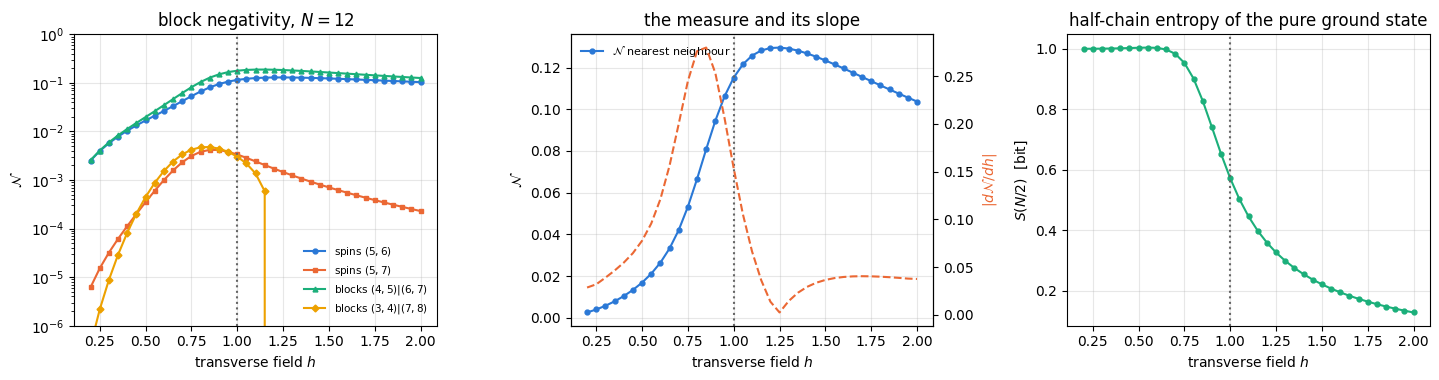

In [16]:
# ==============================================================================
# STEP 13: sweeping the transverse field, N = 12
# ==============================================================================
N_sw = 12
h_grid = np.round(np.arange(0.20, 2.01, 0.05), 3)
t0 = time.time()
records, parity_sweep = [], []
for h in h_grid:
    _, psi_h = lanczos_ground_state(tfim_terms(N_sw, float(h)), N_sw, m=50, restarts=2)
    parity_sweep.append(parity_expectation(psi_h))          # which sector?  checked at EVERY field
    records.append((
        block_negativity(psi_h, (5,), (6,))[0],            # nearest neighbours
        block_negativity(psi_h, (5,), (7,))[0],            # next-nearest neighbours
        block_negativity(psi_h, (4, 5), (6, 7))[0],        # two adjacent 2-spin blocks
        block_negativity(psi_h, (3, 4), (7, 8))[0],        # 2-spin blocks with 2 spins in between
        float(entanglement_entropy(psi_h, tuple(range(N_sw // 2)))),
    ))
nn, nnn, bb, bb2, S_half = map(np.array, zip(*records))
print(f"{len(h_grid)} ground states in {time.time()-t0:.1f} s;  smallest <P> over the sweep = {min(parity_sweep):.10f}")
assert min(parity_sweep) > 1 - 1e-8

def peak(x):
    i = int(np.argmax(x)); return h_grid[i], x[i]

for lbl, arr in [("nearest neighbour", nn), ("next-nearest", nnn),
                 ("adjacent 2+2 blocks", bb), ("2+2 blocks, gap 2", bb2)]:
    hp, vp = peak(arr)
    print(f"  {lbl:22s}: maximum {vp:.6f} at h = {hp:.2f}")
# where on the field axis is each measure non-zero at all?  (a log plot hides the difference between
# "very small" and "exactly zero", so the window is printed explicitly)
for lbl, arr in [("next-nearest", nnn), ("2+2 blocks, gap 2", bb2)]:
    nz = np.flatnonzero(arr > 0.0)
    window = f"{h_grid[nz[0]]:.2f} <= h <= {h_grid[nz[-1]]:.2f}, exactly zero outside" if nz.size else "nowhere"
    print(f"  {lbl:22s}: non-zero on {window}")
d_nn = np.gradient(nn, h_grid)
print(f"  |d N_nn / dh| is largest at h = {h_grid[int(np.argmax(np.abs(d_nn)))]:.2f}")
print(f"  half-chain entropy S(N/2) is largest at h = {h_grid[int(np.argmax(S_half))]:.2f} "
      f"(value {S_half.max():.4f} bit)")

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
axes[0].plot(h_grid, nn, "o-", ms=3.5, label=r"spins $(5,6)$")
axes[0].plot(h_grid, nnn, "s-", ms=3.5, label=r"spins $(5,7)$")
axes[0].plot(h_grid, bb, "^-", ms=3.5, label=r"blocks $(4,5)\vert(6,7)$")
axes[0].plot(h_grid, bb2, "D-", ms=3.5, label=r"blocks $(3,4)\vert(7,8)$")
axes[0].axvline(1.0, color="0.4", ls=":"); axes[0].set_yscale("log"); axes[0].set_ylim(1e-6, 1)
axes[0].set_xlabel(r"transverse field $h$"); axes[0].set_ylabel(r"$\mathcal{N}$")
axes[0].set_title(rf"block negativity, $N={N_sw}$"); axes[0].legend(fontsize=7.5)

axes[1].plot(h_grid, nn, "o-", ms=3.5, color=PALETTE[0], label=r"$\mathcal{N}$ nearest neighbour")
axes[1].axvline(1.0, color="0.4", ls=":")
axes[1].set_xlabel(r"transverse field $h$"); axes[1].set_ylabel(r"$\mathcal{N}$")
ax2 = axes[1].twinx()
ax2.plot(h_grid, np.abs(d_nn), "--", color=PALETTE[1], label=r"$\vert d\mathcal{N}/dh\vert$")
ax2.set_ylabel(r"$\vert d\mathcal{N}/dh\vert$", color=PALETTE[1]); ax2.grid(False)
axes[1].set_title("the measure and its slope")
axes[1].legend(fontsize=8, loc="upper left")

axes[2].plot(h_grid, S_half, "o-", ms=3.5, color=PALETTE[2])
axes[2].axvline(1.0, color="0.4", ls=":")
axes[2].set_xlabel(r"transverse field $h$"); axes[2].set_ylabel(r"$S(N/2)$  [bit]")
axes[2].set_title("half-chain entropy of the pure ground state")
fig.tight_layout(); plt.show()

The measured maxima are **not** at $h=1$, and they are not even at the same place for different blocks: the
nearest-neighbour negativity peaks at $h=1.25$, the two adjacent two-spin blocks at $h=1.15$, and both longer-ranged
quantities — the next-nearest pair and the blocks separated by two spins — at $h=0.85$. A maximum whose position depends on
which pair of blocks one happens to ask about cannot be a signature of criticality, and it is not one.

The two long-ranged curves end differently, and the printed windows say how. The next-nearest pair stays entangled over the
whole sweep, $0.20\le h\le2.00$; it is small at both ends but never zero. The $(3,4)\vert(7,8)$ blocks switch off
completely above $h=1.15$, which the left panel shows as a vertical drop. Deep in the paramagnetic phase the ground state
approaches the product $\vert+\cdots+\rangle$, so the entanglement at every separation decreases. The block negativity at a
separation of three sites reaches zero exactly, at a finite field, where its partial transpose becomes positive. A
logarithmic axis cannot show the difference between small and zero, which is why the window is printed as a number.

What does carry the critical information is the **derivative**. On this grid $\vert d\mathcal N_{\rm nn}/dh\vert$ is largest
at $h=0.85$, i.e. below the critical field. That is the finite-size version of the structure Osterloh, Amico, Falci and
Fazio (2002) identified for the concurrence of the same chain: the pairwise entanglement measure itself is a smooth,
non-universal function whose maximum is unrelated to the transition, while its derivative develops a logarithmic divergence
at the critical point in the thermodynamic limit, its finite-size extremum approaching the critical coupling as the chain
grows. The next cell measures that approach directly.

> **Comparing with the literature: translate the coupling first.** Osterloh et al. parametrise the same chain by
> $\lambda=J/2h$, the inverse of our $h/J$, so their critical point $\lambda_c=1$ is our $h=1$ but their *directions are
> reversed*. They find the extremum of $\partial_\lambda C$ at $\lambda_m\simeq\lambda_c+N^{-1.87}$, i.e. *above* $\lambda_c$,
> which is $h_m$ *below* $1$ — the side on which we measure it ($h=0.75$, $0.80$, $0.85$). They likewise place the maximum of
> the concurrence itself below $\lambda_c$, which is above $h=1$, and that too is what the table shows ($h=1.20$–$1.25$).
> Both comparisons come out right only because the inversion was applied; quoting "the maximum lies below the critical
> coupling" without saying in which variable would reverse the physics. Two further differences of convention are worth
> keeping in mind: they use a periodic chain and the thermodynamic limit, and their quantity is the concurrence, which for
> the nearest-neighbour pair at the chain centre equals $2\mathcal N$ exactly (Section 9.2: reflection symmetry), so $\vert dC/dh\vert=2\vert d\mathcal N/dh\vert$
> and the two curves have their extrema at the same $h$.

The half-chain entropy in the right panel is the pure-state counterpart, and it behaves quite differently. It sits on a
plateau within $0.5\,\%$ of one bit for $h\le0.70$. The nominal maximum, $1.0041$ bit at $h=0.55$, is a small bump on
that plateau. Beyond it the entropy falls monotonically, steeply from $h\approx0.75$ (still on the ordered side of the
transition) and on into the paramagnetic phase. The plateau is the signature of the parity-even ground state identified in Section 9.1. When the two
ferromagnetic branches are distinguishable on each half of the chain, the cat carries one bit across the cut on top of the
small entanglement of each branch. On six sites the branches become less distinguishable as the magnetisation drops, and the
bit is lost before $h=1$. Section 9.1 shows the same effect at $N=8$, $h=0.6$: $0.97$ bit for the cat, below the $1+0.014$ bit that independent branches would give.

> **Numerical practice.** At $h<1$ the open TFIM has two eigenstates of opposite parity separated by a gap that closes
> exponentially with $N$, and every quantity in this section depends on which of them — or which combination — is used.
> It is tempting to assume that the solver picks an arbitrary combination and that short-range quantities are insensitive to
> the choice. Section 9.1 measured both halves. With the settings used here the restarted Lanczos returns the exact
> parity-even eigenvector at every field of the sweep, down to $h=0.2$ where the splitting is $\sim10^{-8}$, but a single
> short pass returns a mixture of the two sectors. And the short-range quantities are not insensitive: at $h=0.6$ the
> nearest-neighbour negativity of the cat is $1.55$ times that of a broken branch ($0.0398$ against $0.0257$), and the
> next-nearest-neighbour one is non-zero for the cat and exactly zero for the branch. The lesson is not "short-range observables are safe" but "state the symmetry
> sector, and check it with an operator" — here one line, $\langle\prod_iX_i\rangle$.

two extra field sweeps in 5.9 s

  N  h at max of N   h at max of |dN/dh|  max |dN/dh|
  8           1.20                  0.75       0.2627
 10           1.20                  0.80       0.2725
 12           1.25                  0.85       0.2800


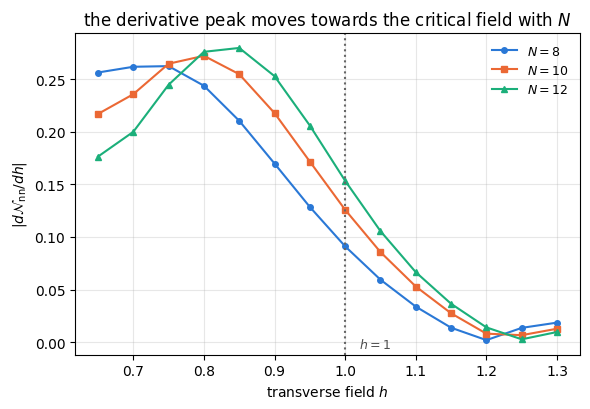

In [17]:
# ==============================================================================
# STEP 13b: where the derivative peaks, as a function of system size
# ==============================================================================
h_fine = np.round(np.arange(0.65, 1.31, 0.05), 3)
drift = {}
t0 = time.time()
for Nf in (8, 10):
    c = Nf // 2
    psis = [lanczos_ground_state(tfim_terms(Nf, float(h)), Nf, m=50, restarts=2)[1] for h in h_fine]
    assert min(parity_expectation(p) for p in psis) > 1 - 1e-8          # parity-even at every field, as at N = 12
    y = np.array([block_negativity(p, (c - 1,), (c,))[0] for p in psis])
    drift[Nf] = (y, np.gradient(y, h_fine))
# N = 12 is already in the big sweep; restrict it to the same window for a fair comparison
mask = (h_grid >= h_fine[0] - 1e-9) & (h_grid <= h_fine[-1] + 1e-9)
drift[12] = (nn[mask], np.gradient(nn[mask], h_grid[mask]))
print(f"two extra field sweeps in {time.time()-t0:.1f} s\n")

print(f"{'N':>3s} {'h at max of N':>14s} {'h at max of |dN/dh|':>21s} {'max |dN/dh|':>12s}")
for Nf in (8, 10, 12):
    y, d = drift[Nf]
    hh = h_fine if Nf < 12 else h_grid[mask]
    print(f"{Nf:3d} {hh[int(np.argmax(y))]:14.2f} {hh[int(np.argmax(np.abs(d)))]:21.2f} {np.max(np.abs(d)):12.4f}")

fig, ax = plt.subplots(figsize=(6.0, 4.2))
for j, Nf in enumerate((8, 10, 12)):
    y, d = drift[Nf]
    hh = h_fine if Nf < 12 else h_grid[mask]
    ax.plot(hh, np.abs(d), MARKERS[j] + "-", ms=4, label=f"$N={Nf}$")
ax.axvline(1.0, color="0.4", ls=":")
ax.text(1.02, 0.02, r"$h=1$", fontsize=9, color="0.3", transform=ax.get_xaxis_transform())
ax.set_xlabel(r"transverse field $h$"); ax.set_ylabel(r"$\vert d\mathcal{N}_{\rm nn}/dh\vert$")
ax.set_title("the derivative peak moves towards the critical field with $N$")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

The peak of $\vert d\mathcal N_{\rm nn}/dh\vert$ sits at $h=0.75$ for $N=8$, at $h=0.80$ for $N=10$ and at $h=0.85$ for
$N=12$: it moves towards $h=1$ as the chain grows, and its height increases slowly ($0.2627\to0.2725\to0.2800$, a rise of
$6.6\,\%$ while $N$ grows by $50\,\%$). A growth that slow is compatible with the logarithmic divergence of Osterloh et al.,
but three sizes on a grid of spacing $0.05$ cannot distinguish $\ln N$ from any other slowly increasing function, and we do
not fit one. What the measurement does establish is the contrast: the displacement of the *derivative*
peak from $h=1$ shrinks with $N$, while the displacement of the maximum of $\mathcal N$ itself ($h=1.20$, $1.20$, $1.25$ for
the same three sizes) does not shrink at all. On twelve spins, read the critical point off the derivative, not off the
measure.

## 10. Dynamics

### 10.1 The light cone of block negativity after a quench

Prepare the paramagnetic product state $\vert+\rangle^{\otimes N}$ — the ground state of Eq. (16) at $h=\infty$ — and switch
the Hamiltonian on at $h=1$ at $t=0$. Information spreads at a finite maximal speed (a Lieb–Robinson bound), so two blocks
far apart cannot become entangled before that speed has carried a signal between them. For the TFIM the quasiparticle
dispersion is $\varepsilon(k)=2\sqrt{1+h^2-2h\cos k}$ and the maximal group velocity at $h=1$ is
$v_{\max}=\max_k\vert d\varepsilon/dk\vert=2$ sites per unit time. Two blocks whose nearest members are $\ell$ sites apart
should therefore stay unentangled until roughly $t\approx\ell/(2v_{\max})$ — quasiparticles are created in pairs and travel in
opposite directions, so each of the two halves of a pair covers half of the distance.

We evolve with second-order TEBD from [notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)
and record four block negativities at every step through the `observe` hook of `tebd_evolve`, which runs the whole time loop
inside one `lax.scan`.

TEBD: 120 steps of dt = 0.05 on 10 spins in 1.5 s
norm of the final state: 1.000000000000

first time at which N > 0.0001:
  $(3,4)\vert(5,6)$, $\ell=1$   separation 1:  t_on = 0.05   (peak 0.4384 at t = 2.95)
  $(2,3)\vert(6,7)$, $\ell=3$   separation 3:  t_on = 0.80   (peak 0.3112 at t = 2.90)
  $(1,2)\vert(7,8)$, $\ell=5$   separation 5:  t_on = 1.65   (peak 0.2382 at t = 2.90)
  $(0..3)\vert(4..7)$, $\ell=1$  separation 1:  t_on = 0.05   (peak 1.2183 at t = 2.90)

onset time t_on as a function of the detection threshold
 threshold    l = 1    l = 3    l = 5
     1e-02     0.05     0.85     1.75
     1e-03     0.05     0.80     1.65
     1e-04     0.05     0.80     1.65
     1e-06     0.05     0.80     1.35
     1e-08     0.05     0.80     1.35
     1e-10     0.05     0.80     1.35
  quasiparticle estimate: t_on = l/(2 v_max) = l/4 -> 0.25 0.75 1.25
  N is EXACTLY zero before the front arrives: largest value on (l=3) before t = 0.75 is 0.0e+00


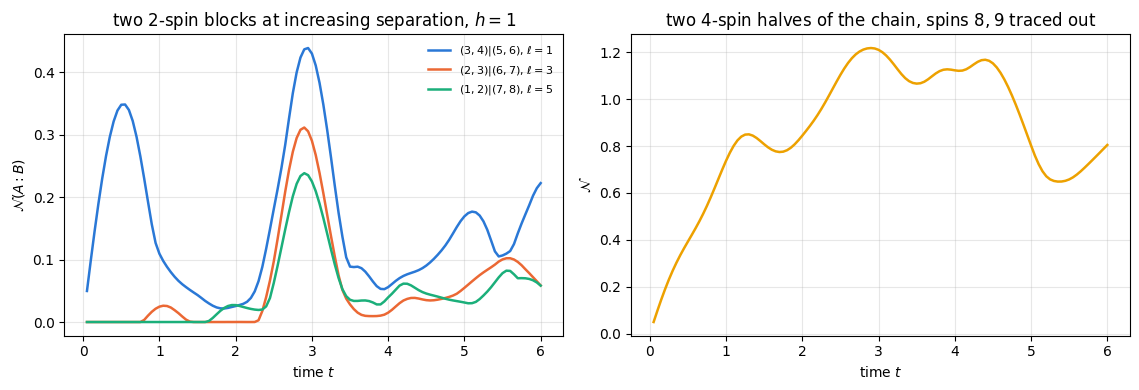

In [18]:
# ==============================================================================
# STEP 14: quench |+>^N -> TFIM(h=1); block negativity vs time (pure state, N = 10)
# ==============================================================================
N_q, h_q, dt_q, n_steps_q = 10, 1.0, 0.05, 120
terms_q = tfim_terms(N_q, h_q)
configs = [((3, 4), (5, 6), 1), ((2, 3), (6, 7), 3), ((1, 2), (7, 8), 5), ((0, 1, 2, 3), (4, 5, 6, 7), 1)]
labels = [r"$(3,4)\vert(5,6)$, $\ell=1$", r"$(2,3)\vert(6,7)$, $\ell=3$",
          r"$(1,2)\vert(7,8)$, $\ell=5$", r"$(0..3)\vert(4..7)$, $\ell=1$"]


def observe_neg(psi):
    """Negativities of the four block pairs, as one stacked array -- the `observe` hook of tebd_evolve."""
    out = []
    for A, B, _ in configs:
        rho_AB = rdm(psi, A + B)
        out.append(negativity(dm_tensor(rho_AB, len(A) + len(B)), list(range(len(A))))[0])
    return jnp.stack(out)


t0 = time.time()
psi_final, traj = tebd_evolve(product_state("+" * N_q), terms_q, dt_q, n_steps_q, order=2, observe=observe_neg)
traj = np.asarray(jax.block_until_ready(traj))
ts_q = np.arange(1, n_steps_q + 1) * dt_q
print(f"TEBD: {n_steps_q} steps of dt = {dt_q} on {N_q} spins in {time.time()-t0:.1f} s")
print(f"norm of the final state: {float(jnp.linalg.norm(psi_final)):.12f}")

thr = 1e-4
print(f"\nfirst time at which N > {thr}:")
for j, (A, B, ell) in enumerate(configs):
    idx = np.flatnonzero(traj[:, j] > thr)
    t_on = ts_q[idx[0]] if idx.size else np.inf
    print(f"  {labels[j]:28s}  separation {ell}:  t_on = {t_on:.2f}   "
          f"(peak {traj[:, j].max():.4f} at t = {ts_q[int(np.argmax(traj[:, j]))]:.2f})")

# ------------------------------------------------------------------------------
# To check whether the onset is an artefact of the threshold, we vary the threshold.
# ------------------------------------------------------------------------------
print(f"\nonset time t_on as a function of the detection threshold\n{'threshold':>10s}" +
      "".join(f"{'l = %d' % c[2]:>9s}" for c in configs[:3]))
for thr_scan in (1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10):
    t_on = []
    for j in range(3):
        idx = np.flatnonzero(traj[:, j] > thr_scan)
        t_on.append(ts_q[idx[0]] if idx.size else np.inf)
    print(f"{thr_scan:10.0e}" + "".join(f"{t:9.2f}" for t in t_on))
print(f"  quasiparticle estimate: t_on = l/(2 v_max) = l/4 -> {0.25:.2f} {0.75:.2f} {1.25:.2f}")
print(f"  N is EXACTLY zero before the front arrives: largest value on (l=3) before t = 0.75 is "
      f"{traj[ts_q < 0.75, 1].max():.1e}")
assert traj[ts_q < 0.70, 1].max() == 0.0 and traj[ts_q < 1.20, 2].max() == 0.0

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for j in range(3):
    axes[0].plot(ts_q, traj[:, j], lw=1.8, label=labels[j])
axes[0].set_xlabel("time $t$"); axes[0].set_ylabel(r"$\mathcal{N}(A{:}B)$")
axes[0].set_title(r"two 2-spin blocks at increasing separation, $h=1$"); axes[0].legend(fontsize=8)
axes[1].plot(ts_q, traj[:, 3], lw=1.8, color=PALETTE[3])
axes[1].set_xlabel("time $t$"); axes[1].set_ylabel(r"$\mathcal{N}$")
axes[1].set_title(r"two 4-spin halves of the chain, spins $8,9$ traced out")
fig.tight_layout(); plt.show()

Ten spins is a short chain for a front that moves four sites per unit time, so before interpreting these onsets we check
which of them survive a change of $N$. The next cell repeats the quench for the same three block pairs, always centred, in
chains of $N=10$, $14$ and $18$ spins. Next to the onset of the negativity (first step with $\mathcal N>0$) it records the
first time at which the correlator $\langle Z_iZ_j\rangle$ between the two nearest members of the blocks exceeds $10^{-2}$.
The quench starts from a parity-even state, so $\langle Z_i\rangle=0$ at all times and this correlator is already the
connected one. A property of the light cone must not depend on $N$; a finite-size effect must.

In [19]:
# ==============================================================================
# STEP 14b: the same quench in longer chains -- which onsets are light-cone physics?
# ==============================================================================
def quench_onsets(N, n_steps=120):
    """Onset of N(A:B) > 0, first time |<Z_i Z_j>| > 1e-2 (i, j = nearest members), and time of the largest N,
    for centred block pairs at separations l = 1, 3, 5 after the quench |+>^N -> TFIM(h=1)."""
    c = N // 2
    cfg = [((c - 2 - k, c - 1 - k), (c + k, c + 1 + k)) for k in (0, 1, 2)]       # l = 2k + 1

    def obs(psi):
        out = []
        for A, B in cfg:
            out.append(negativity(dm_tensor(rdm(psi, A + B), 4), [0, 1])[0])
            out.append(jnp.real(jnp.vdot(psi, apply_gate(psi, ZZ_, [A[1], B[0]]))))
        return jnp.stack(out)

    _, tr = tebd_evolve(product_state("+" * N), tfim_terms(N, 1.0), dt_q, n_steps, order=2, observe=obs)
    tr = np.asarray(jax.block_until_ready(tr))
    ts = np.arange(1, n_steps + 1) * dt_q
    first = lambda mask: ts[np.flatnonzero(mask)[0]] if mask.any() else np.inf
    return [(first(tr[:, 2 * j] > 0.0), first(np.abs(tr[:, 2 * j + 1]) > 1e-2), ts[int(np.argmax(tr[:, 2 * j]))])
            for j in range(3)]


t0 = time.time()
size_scan = {N: quench_onsets(N) for N in (10, 14, 18)}
print(f"three quenches (N = 10, 14, 18) in {time.time()-t0:.1f} s\n")
print(f"{'N':>3s}" + "".join(f"{'l=%d: N>0' % l:>11s}{'|ZZ|>1e-2':>11s}{'max N at':>10s}" for l in (1, 3, 5)))
for N, rows in size_scan.items():
    print(f"{N:3d}" + "".join(f"{a:11.2f}{b:11.2f}{c:10.2f}" for a, b, c in rows))
# the l = 1 and l = 3 onsets and the correlator front at l = 5 are the same for every N ...
assert all(size_scan[N][j][0] == size_scan[10][j][0] for N in (14, 18) for j in (0, 1))
assert all(abs(size_scan[N][2][1] - size_scan[10][2][1]) < 1.5 * dt_q for N in (14, 18))
# ... while the l = 5 NEGATIVITY onset is not: reading it as a light-cone time is a hypothesis that fails
assert size_scan[18][2][0] - size_scan[10][2][0] > 2.0

three quenches (N = 10, 14, 18) in 5.6 s

  N   l=1: N>0  |ZZ|>1e-2  max N at   l=3: N>0  |ZZ|>1e-2  max N at   l=5: N>0  |ZZ|>1e-2  max N at
 10       0.05       0.10      2.95       0.80       0.45      2.90       1.35       1.05      2.90
 14       0.05       0.10      0.55       0.80       0.45      4.00       3.35       1.05      4.00
 18       0.05       0.10      0.55       0.80       0.45      5.10       4.50       1.05      5.00


In the $N=10$ run, a threshold of $10^{-4}$ gives onset times $t_{\rm on}=0.05$, $0.80$ and $1.65$ for separations
$\ell=1$, $3$, $5$. The quasiparticle estimate $\ell/(2v_{\max})=\ell/4$ gives $0.25$, $0.75$ and $1.25$. Two checks decide
what these numbers mean. The threshold sweep of Step 14 shows which onsets depend on the detection level. The size scan of
Step 14b shows which ones depend on the length of the chain.

The three separations behave in three different ways.

* At $\ell=3$ the onset is $t_{\rm on}=0.80$ for **every** threshold from $10^{-3}$ down to $10^{-10}$, and for $N=10$, $14$
  and $18$ alike. The negativity is *exactly* $0$ at every earlier step, as the last printed line of Step 14 confirms. It
  jumps to $3.3\cdot10^{-3}$ in a single step of $dt=0.05$. Against $\ell/4=0.75$ this is agreement to one time step. A
  front that is present but too weak to cross the threshold would move when the threshold moves, and this one does not. The
  zero is exact for the following reason. Within the first steps each block becomes entangled with its own neighbours, so
  the reduced state of $A\cup B$ is mixed and the eigenvalues of its partial transpose move from zero to positive values.
  The exponentially small correlations between $A$ and $B$ ahead of the front cannot make one of them negative. The
  negativity switches on only when the correlations carried by the front exceed that margin.
* At $\ell=5$ the $N=10$ onset depends on the threshold: $1.75$, $1.65$, $1.65$ and $1.35$ for thresholds $10^{-2}$,
  $10^{-3}$, $10^{-4}$ and $10^{-6}$ (unchanged below), with a first pulse of height $\sim3\cdot10^{-5}$ at $t=1.35$. It
  also depends on the size, and Step 14b shows this is the decisive fact. The onset moves from $1.35$ at $N=10$ to
  $4.50$ at $N=18$. In the longer chains it lies close to the time of the largest negativity, which grows with $N$ as well.
  The correlator between the same two sites is the same in all three chains: it passes $10^{-2}$ at $t=1.05$, before
  $\ell/4=1.25$. So the light cone does reach these blocks on time, but in a long chain it carries too little to make two
  two-site blocks five sites apart NPT. Their negativity appears only later, at a time set by the chain length, which marks
  a finite-size revival. The $N=10$ onsets at $\ell=5$, and any front speed computed from them,
  are finite-size numbers. Whether such blocks ever become NPT in an infinite chain cannot be decided from $N\le18$.
* At $\ell=1$ the two blocks are *adjacent*: sites $4$ and $5$ share a bond, the very first Trotter gate acts across it, and
  $t_{\rm on}=0.05=dt$ at every threshold and every $N$. This is earlier than $\ell/4=0.25$, and no threshold argument can
  move it. The quasiparticle formula is an asymptotic statement about distances large compared with a lattice spacing; at
  $\ell=1$ the onset is set by the time step, not by the light cone.

What the data establish, then, is a light cone for the *correlations*. The correlator front reaches the $\ell=5$ pair at
the same time in every chain. Block negativity of small blocks follows it only where the arriving correlations are strong
enough, here up to $\ell=3$. Before the onset the negativity is exactly zero. For these $4\times4$ blocks
that is a statement about the partial transpose and not a proof of separability (Section 5.3).

The block negativity then rises and falls back, repeatedly. This is not decoherence — the state is pure and the evolution
unitary. In the long chains, $N\ge14$, the adjacent blocks ($\ell=1$) reach their largest value at $t=0.55$ and then lose
it. A quasiparticle pair that entangles $A$ with $B$ keeps travelling and ends up entangling $A$ with spins outside $B$, and
monogamy forces $\mathcal N(A{:}B)$ back down. The large maxima near $t\approx2.9$ in the $N=10$ figure are of a different
kind. Step 14b shows the time of the largest negativity growing with the chain length, which is the signature of
quasiparticles reflected at the open ends. The right panel, where $A\cup B$ is eight of the ten spins, shows the same
oscillation on top of a much larger value, because far more quasiparticle pairs are shared.

### 10.2 Entanglement sudden death

Under local noise the entanglement of a pair does not decay exponentially and vanish only asymptotically. It can reach
**exactly zero at a finite time** and stay there while the coherences that produced it are still non-zero. Yu and Eberly
(2004) showed this for two atoms decaying by spontaneous emission; the name **entanglement sudden death**, under which their
2009 review collects the subject, came into use afterwards.

Take the initial pure state

$$\vert\psi_0\rangle=\sqrt a\,\vert00\rangle+\sqrt b\,\vert11\rangle,\qquad b=1-a ,$$

and let both qubits undergo amplitude damping with $\gamma(t)=1-e^{-\Gamma t}$: $\vert1\rangle$ decays to $\vert0\rangle$ with
probability $\gamma$. Applying the Kraus pair $K_0=\mathrm{diag}(1,\sqrt{1-\gamma})$, $K_1=\sqrt\gamma\,\vert0\rangle\langle1\vert$
to each qubit gives, in the basis $\vert00\rangle,\vert01\rangle,\vert10\rangle,\vert11\rangle$,

$$\rho(t)=\begin{pmatrix}a+b\gamma^2&0&0&\sqrt{ab}\,(1-\gamma)\\
0&b\gamma(1-\gamma)&0&0\\ 0&0&b\gamma(1-\gamma)&0\\
\sqrt{ab}\,(1-\gamma)&0&0&b(1-\gamma)^2\end{pmatrix} . \tag{17}$$

(The $\vert11\rangle$ population loses one factor $(1-\gamma)$ per qubit; each single decay feeds
$\vert01\rangle$ or $\vert10\rangle$ with weight $b\gamma(1-\gamma)$; both decaying feeds $\vert00\rangle$ with $b\gamma^2$;
and the coherence, which requires "no decay" on both sides of $\vert11\rangle\langle00\vert$, picks up
$\sqrt{1-\gamma}$ twice.)

Partial-transposing the $A$ index exchanges the corner element $\rho_{00,11}$ with the middle element $\rho_{01,10}=0$, so
$\rho^{T_A}$ is block diagonal with one $2\times2$ block
$\begin{pmatrix}b\gamma(1-\gamma)&\sqrt{ab}(1-\gamma)\\ \sqrt{ab}(1-\gamma)&b\gamma(1-\gamma)\end{pmatrix}$
whose smaller eigenvalue is $(1-\gamma)\bigl[b\gamma-\sqrt{ab}\bigr]$. Hence

$$\mathcal N(t)=(1-\gamma)\,\max\left(0,\ \sqrt{ab}-b\gamma\right) , \tag{18}$$

which reaches zero at

$$\gamma^*=\sqrt{a/b}\qquad\Longrightarrow\qquad
  \Gamma t^*=-\ln\Bigl(1-\sqrt{a/b}\Bigr)\quad\text{if }a<b , \tag{19}$$

and never at all if $a\ge b$, because then $\gamma^*\ge1$ is out of range. **Whether entanglement dies at a finite time
depends on the initial state**, and the transition is at $a=b=1/2$.

     a      N(0)  measured Gamma t*     Eq. (19)   max|N - Eq.(18)|
  0.10   0.30000             0.4100       0.4055           1.39e-16
  0.25   0.43301             0.8650       0.8612           1.67e-16
  0.40   0.48990             1.7000       1.6955           1.67e-16
  0.50   0.50000                inf          inf           2.22e-16
  0.75   0.43301                inf          inf           1.11e-16

a = 0.25: death time vs decay rate (Eq. (19) scaled by 1/Gamma)
  Gamma = 0.25:  measured t* = 3.4450,  predicted 3.4448,  Gamma t* = 0.8613
  Gamma = 0.50:  measured t* = 1.7250,  predicted 1.7224,  Gamma t* = 0.8625
  Gamma = 1.00:  measured t* = 0.8650,  predicted 0.8612,  Gamma t* = 0.8650
  Gamma = 2.00:  measured t* = 0.4350,  predicted 0.4306,  Gamma t* = 0.8700
  Gamma = 4.00:  measured t* = 0.2200,  predicted 0.2153,  Gamma t* = 0.8800


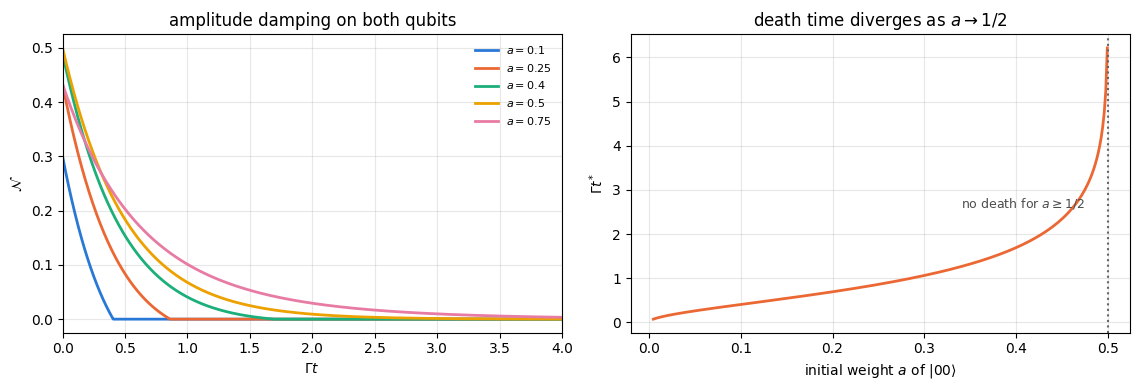

In [20]:
# ==============================================================================
# STEP 15: entanglement sudden death, measured against Eqs. (18)-(19)
# ==============================================================================
@jax.jit
def _esd_one(a, g):
    """Negativity of Eq. (17) for one initial weight a and one damping parameter gamma.
    JAX: a and g are traced scalars, so the whole curve is one `vmap` over the gamma grid."""
    psi0 = jnp.stack([jnp.sqrt(a), 0.0 * a, 0.0 * a, jnp.sqrt(1 - a)]).astype(CDTYPE).reshape(2, 2)
    r = to_dm(psi0)
    for q in (0, 1):
        r = apply_kraus_dm(r, kraus_amplitude_damping(g), [q])
    return negativity(r, [0])[0]


def esd_curve(a, gammas):
    """Negativity along a whole damping sweep, vmapped over gamma (one batched call, no Python loop)."""
    return np.asarray(jax.vmap(_esd_one, in_axes=(None, 0))(jnp.asarray(a, RDTYPE),
                                                            jnp.asarray(gammas, RDTYPE)))


Gamma = 1.0
t_grid = np.linspace(0, 4, 801)
gam_grid = 1 - np.exp(-Gamma * t_grid)
a_values = [0.10, 0.25, 0.40, 0.50, 0.75]

print(f"{'a':>6s} {'N(0)':>9s} {'measured Gamma t*':>18s} {'Eq. (19)':>12s} {'max|N - Eq.(18)|':>18s}")
curves = {}
for a in a_values:
    y = esd_curve(a, gam_grid)
    curves[a] = y
    ana = (1 - gam_grid) * np.maximum(0.0, np.sqrt(a * (1 - a)) - (1 - a) * gam_grid)
    idx = np.flatnonzero(y <= 1e-12)
    t_meas = t_grid[idx[0]] if idx.size else np.inf
    t_exact = -np.log(1 - np.sqrt(a / (1 - a))) if a < 0.5 else np.inf
    print(f"{a:6.2f} {y[0]:9.5f} {t_meas:18.4f} {t_exact:12.4f} {np.max(np.abs(y - ana)):18.2e}")
    assert np.max(np.abs(y - ana)) < 1e3 * TOL

# death time as a function of the decay RATE at fixed a: t* scales as 1/Gamma
a_fix = 0.25
rates = np.array([0.25, 0.5, 1.0, 2.0, 4.0])
t_star_exact = -np.log(1 - np.sqrt(a_fix / (1 - a_fix))) / rates
print(f"\na = {a_fix}: death time vs decay rate (Eq. (19) scaled by 1/Gamma)")
for G_, ts_ in zip(rates, t_star_exact):
    y = esd_curve(a_fix, 1 - np.exp(-G_ * t_grid))
    idx = np.flatnonzero(y <= 1e-12)
    print(f"  Gamma = {G_:4.2f}:  measured t* = {t_grid[idx[0]]:.4f},  predicted {ts_:.4f},  Gamma t* = {G_*t_grid[idx[0]]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for a in a_values:
    axes[0].plot(t_grid, curves[a], lw=2, label=rf"$a={a}$")
axes[0].set_xlabel(r"$\Gamma t$"); axes[0].set_ylabel(r"$\mathcal{N}$")
axes[0].set_title("amplitude damping on both qubits"); axes[0].legend(fontsize=8); axes[0].set_xlim(0, 4)
aa = np.linspace(0.005, 0.499, 300)
axes[1].plot(aa, -np.log(1 - np.sqrt(aa / (1 - aa))), lw=2, color=PALETTE[1])
axes[1].axvline(0.5, color="0.4", ls=":")
axes[1].text(0.34, 2.6, r"no death for $a\geq 1/2$", fontsize=9, color="0.3")
axes[1].set_xlabel(r"initial weight $a$ of $\vert 00\rangle$"); axes[1].set_ylabel(r"$\Gamma t^{*}$")
axes[1].set_title("death time diverges as $a\\to 1/2$")
fig.tight_layout(); plt.show()

Eq. (18) reproduces the measured curves to $10^{-16}$ over the whole time axis, and the measured death times match Eq. (19)
to within the grid step of $0.005$: $\Gamma t^*=0.4100$ against $0.4055$ for $a=0.10$, $0.8650$ against $0.8612$ for
$a=0.25$, $1.7000$ against $1.6955$ for $a=0.40$. Each measured value is the *first* grid point at which the negativity has
already vanished, so it is one step late by construction. For $a=0.50$ and $a=0.75$ the negativity never reaches zero at
all, exactly as Eq. (19) says. The rate scan confirms that $t^*$ is inversely proportional to $\Gamma$: the product
$\Gamma t^*$ comes out as $0.8613$, $0.8625$, $0.8650$, $0.8700$, $0.8800$ for $\Gamma=0.25,\dots,4$, drifting upward only
because a fixed time grid resolves a shorter $t^*$ more coarsely. Sudden death is a statement about the accumulated damping
$\gamma$, not about the clock.

> **Physics insight.** Nothing singular happens to the state at $t^*$: the coherence $\rho_{00,11}$ is still non-zero and
> decays smoothly to zero only as $t\to\infty$. What happens is that the *populations* $\rho_{01,01}$ and $\rho_{10,10}$
> fed by single decay events grow fast enough to outweigh it. In this model the state stays separable after $t^*$: the
> evolution from $t^*$ to any later time is again a product of local channels, which map separable states to separable
> states. Section 10.3 shows that this argument fails once the qubits also interact, and there the negativity can return.
> Sudden death is a property of the boundary of the set of separable states, not of any physical process being switched off.
> It has been observed in photonic and atomic experiments; Yu and Eberly (2009) review them.

### 10.3 Sudden death in a many-body quench

The same happens in the chain. Repeat the quench of Section 10.1 on $N=6$ spins, now on the **density tensor**, with a local
dephasing channel of rate $\gamma$ applied to every spin after every Trotter step. One Trotter step of the Lindblad dynamics is
`apply_gates_dm` followed by one Kraus channel per site, with $p=\gamma\,dt/2$ so that the coherence decays as
$(1-2p)^{t/dt}\approx e^{-\gamma t}$.

5 noisy quenches of 200 steps on 6 spins (density tensor): 1.2 s

 gamma     peak N   t(peak)   t_death  gamma * t_death
  0.00   0.553301      2.00       inf              inf
  0.10   0.305679      0.50      5.60            0.560
  0.30   0.233847      0.45      2.40            0.720
  0.60   0.153763      0.40      1.00            0.600
  1.00   0.080283      0.30      0.70            0.700



fine scan:  gamma   t_death   gamma * t_death
            0.10      5.60       0.560
            0.15      3.20       0.480
            0.20      2.95       0.590
            0.25      2.65       0.663
            0.30      2.40       0.720
            0.35      2.20       0.770
            0.40      1.65       0.660
            0.45      1.25       0.562
            0.50      1.15       0.575
            0.55      1.05       0.578
            0.60      1.00       0.600
            0.65      0.95       0.618
            0.70      0.90       0.630
            0.75      0.85       0.638
            0.80      0.80       0.640
            0.85      0.80       0.680
            0.90      0.75       0.675
            0.95      0.70       0.665
            1.00      0.70       0.700
gamma * t_death spans 0.48 ... 0.77; drops larger than 0.05: 0.10->0.15 (0.08), 0.35->0.40 (0.11), 0.40->0.45 (0.10)


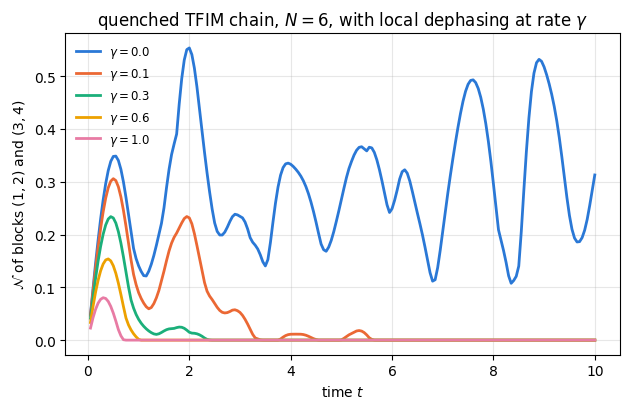

In [21]:
# ==============================================================================
# STEP 16: noisy quench on the density tensor, N = 6 -- block negativity dies at a finite time
# ==============================================================================
N_n, dt_n, n_steps_n = 6, 0.05, 200
gates_n = tebd_gates(tfim_terms(N_n, 1.0), dt_n, 2)
A_n, B_n = (1, 2), (3, 4)


@partial(jax.jit, static_argnums=())
def noisy_quench(rho0, kraus):
    """One trajectory-free (exact) noisy evolution: TEBD gates then one dephasing channel per site, scanned."""
    def step(rho, _):
        rho = apply_gates_dm(rho, gates_n)
        for q in range(N_n):
            rho = apply_kraus_dm(rho, kraus, [q])
        rho_AB = rdm_dm(rho, A_n + B_n)
        n = negativity(dm_tensor(rho_AB, 4), [0, 1])[0]
        return rho, n
    return lax.scan(step, rho0, None, length=n_steps_n)


rho0_n = to_dm(product_state("+" * N_n))
ts_n = np.arange(1, n_steps_n + 1) * dt_n
gammas = [0.0, 0.1, 0.3, 0.6, 1.0]
t0 = time.time()
out = {}
for g in gammas:
    _, y = noisy_quench(rho0_n, kraus_dephasing(g * dt_n / 2))
    out[g] = np.asarray(jax.block_until_ready(y))
print(f"5 noisy quenches of {n_steps_n} steps on {N_n} spins (density tensor): {time.time()-t0:.1f} s")

# "death time" = the LAST time at which the negativity is still non-zero.  The unitary part makes the
# curve oscillate, so it can touch zero in a trough and come back; only the last crossing is a death.
print(f"\n{'gamma':>6s} {'peak N':>10s} {'t(peak)':>9s} {'t_death':>9s} {'gamma * t_death':>16s}")
for g in gammas:
    y = out[g]
    nz = np.flatnonzero(y > 1e-12)
    t_d = ts_n[nz[-1]] if (nz.size and nz[-1] < len(y) - 1) else np.inf
    print(f"{g:6.2f} {y.max():10.6f} {ts_n[int(np.argmax(y))]:9.2f} {t_d:9.2f} "
          f"{g*t_d if np.isfinite(t_d) else np.inf:16.3f}")


def death_time(y):
    nz = np.flatnonzero(y > 1e-12)
    return ts_n[nz[-1]] if (nz.size and nz[-1] < len(y) - 1) else np.inf


# Is the scatter of gamma * t_death caused by the oscillation, as the text claims?  Then t_death must change in
# JUMPS (the last crossing moves to an earlier lobe) and drift smoothly in between.  A finer gamma grid decides.
g_fine = np.round(np.arange(0.10, 1.001, 0.05), 3)
td_fine = np.array([death_time(np.asarray(noisy_quench(rho0_n, kraus_dephasing(g * dt_n / 2))[1])) for g in g_fine])
print("\nfine scan:  gamma   t_death   gamma * t_death")
for g, td in zip(g_fine, td_fine):
    print(f"           {g:5.2f}  {td:8.2f}  {g * td:10.3f}")
# a smooth t_death ~ c / gamma would keep gamma * t_death flat; a sawtooth (slow rise, sudden drop) means jumps between lobes
gt = g_fine * td_fine
drops = [(g_fine[i], g_fine[i + 1], gt[i] - gt[i + 1]) for i in range(len(gt) - 1) if gt[i] - gt[i + 1] > 0.05]
print(f"gamma * t_death spans {gt.min():.2f} ... {gt.max():.2f}; drops larger than 0.05: "
      + ", ".join(f"{a:.2f}->{b:.2f} ({d:.2f})" for a, b, d in drops))

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for g in gammas:
    ax.plot(ts_n, out[g], lw=2, label=rf"$\gamma={g}$")
ax.set_xlabel("time $t$"); ax.set_ylabel(r"$\mathcal{N}$ of blocks $(1,2)$ and $(3,4)$")
ax.set_title(rf"quenched TFIM chain, $N={N_n}$, with local dephasing at rate $\gamma$")
ax.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

Without noise the block negativity keeps oscillating for the whole run and is still non-zero at $t=10$. With dephasing it is
cut off for good at a finite time: $t_{\rm death}=5.60$, $2.40$, $1.00$ and $0.70$ for $\gamma=0.1$, $0.3$, $0.6$ and $1.0$.
The products $\gamma\,t_{\rm death}=0.56$, $0.72$, $0.60$, $0.70$ are constant to within $30\,\%$ across a factor of ten in
rate, so here too what decides the death is roughly the accumulated dephasing, not the elapsed time. The spread is larger
than in the two-qubit model because the unitary part makes the curve oscillate: the last crossing can fall on a different
lobe when the envelope is shifted slightly. The fine scan tests this explanation. Over $0.10\le\gamma\le1$ the product
$\gamma\,t_{\rm death}$ spans $0.48$–$0.77$, so the four-point table understates the scatter. The product traces a
sawtooth: it rises slowly while the last crossing stays on one lobe, then drops when the
crossing moves to an earlier lobe, between $\gamma=0.10$ and $0.15$ and again between $0.35$ and $0.45$, as printed. A
smooth $t_{\rm death}\propto1/\gamma$ would keep the product flat.

> **Common pitfall.** With an oscillating signal, "the first time the quantity reaches zero" is not the death time: the
> curve can touch zero in a trough and come back, as the $\gamma=0.1$ curve does twice before $t=5.6$. The cell above
> therefore reports the *last* time at which the negativity is still non-zero, and checks that the run is long enough for
> that to be meaningful (at $\gamma=0$ it is not, and the table prints infinity).

## 11. Cost, and how far one can go

Two very different price tags appear in this notebook.

* **Full density tensor.** $\rho$ has $4^N$ complex entries ($16\cdot4^N$ bytes in double precision: $16\,$MB at $N=10$,
  $4.3\,$GB at $N=14$), and the eigenvalues of its partial transpose cost $O(8^N)$: every extra qubit multiplies the time
  by $8$ and the memory by $4$. On one CPU thread the full negativity of a random $N$-qubit state takes about $0.7\,$s at
  $N=10$, $5\,$s at $N=11$ and $40\,$s at $N=12$ (compilation included), so $N=13$ costs minutes and $N=14$ needs
  $4\,$GiB for the tensor alone. This is the route used in Sections 8 and 10.3.
* **Pure state, small blocks.** The state is $2^N$ numbers. The reduced state of $A\cup B$ costs one einsum,
  $O(2^N2^{\vert A\vert+\vert B\vert})$, and its partial transpose costs $O(8^{\vert A\vert+\vert B\vert})$ — independent of
  $N$. For $\vert A\vert+\vert B\vert=4$ that second term is the diagonalisation of a $16\times16$ matrix, which is free. The
  wall is then the state vector itself, $N\approx26$ on a laptop. This is the route of Sections 9 and 10.1.
* **Pure state, full cut.** Eq. (11) needs only the singular values of a $2^{\vert A\vert}\times2^{N-\vert A\vert}$ matrix:
  $O(2^{\min(\vert A\vert,N-\vert A\vert)}2^N)$, again limited only by the state vector.

The benchmark below measures the first two against each other on the same states.

In [22]:
# ==============================================================================
# STEP 17: measured cost of the three routes
# ==============================================================================
print(f"{'N':>3s} {'dim rho':>10s} {'memory rho':>12s} {'PT+eigh [s]':>13s} {'Schmidt [s]':>12s} {'speed-up':>9s} {'|difference|':>13s}")
for Nb in (6, 8, 10, 12):
    psi_b = haar_state(jax.random.PRNGKey(Nb), Nb)
    A = tuple(range(Nb // 2))
    # Schmidt route
    negativity_pure(psi_b, A)[0].block_until_ready()
    t0 = time.time()
    for _ in range(5):
        v = negativity_pure(psi_b, A)[0]
    v.block_until_ready(); t_s = (time.time() - t0) / 5
    # brute-force route (only where the density tensor fits comfortably)
    if Nb <= 10:
        rho_b = to_dm(psi_b)
        negativity(rho_b, list(A))[0].block_until_ready()
        t0 = time.time()
        for _ in range(3):
            w = negativity(rho_b, list(A))[0]
        w.block_until_ready(); t_p = (time.time() - t0) / 3
        print(f"{Nb:3d} {2**Nb:10d} {16*4**Nb/2**20:9.1f} MB {t_p:13.4f} {t_s:12.5f} {t_p/t_s:8.0f}x "
              f"{abs(float(v) - float(w)):13.2e}")
        assert abs(float(v) - float(w)) < 1e-6 * max(1.0, float(v))
    else:
        print(f"{Nb:3d} {2**Nb:10d} {16*4**Nb/2**20:9.1f} MB {'(skipped)':>13s} {t_s:12.5f} {'-':>9s} {'-':>13s}")

print("\nreduced-block route: cost is set by |A|+|B|, not by N")
N_big = 14
psi_big = product_state("+" * N_big)                     # 1D cluster state on 14 spins
for q in range(N_big - 1):
    psi_big = apply_gate(psi_big, CZ, [q, q + 1])
t0 = time.time()
n_big = block_negativity(psi_big, (5, 6), (7, 8))
print(f"  cluster state, blocks (5,6) and (7,8): N = {n_big[0]:.6f}, E_N = {n_big[1]:.6f}  [{time.time()-t0:.3f} s]")
psi_haar14 = haar_state(jax.random.PRNGKey(5), N_big)
t0 = time.time()
n_haar = block_negativity(psi_haar14, (5, 6), (7, 8))
print(f"  Haar-random state, same blocks       : N = {n_haar[0]:.6f}, E_N = {n_haar[1]:.6f}  [{time.time()-t0:.3f} s]"
      f"   min spec(PT) = {pt_min_eigenvalue(rdm(psi_haar14, (5, 6, 7, 8)), 2, 2):+.4f}")
print(f"  the full density tensor of {N_big} spins would need {16*4**N_big/2**30:.1f} GiB")

  N    dim rho   memory rho   PT+eigh [s]  Schmidt [s]  speed-up  |difference|


  6         64       0.1 MB        0.0005      0.00017        3x      0.00e+00
  8        256       1.0 MB        0.0093      0.00017       56x      2.66e-15


 10       1024      16.0 MB        0.4949      0.00023     2139x      0.00e+00
 12       4096     256.0 MB     (skipped)      0.00053         -             -

reduced-block route: cost is set by |A|+|B|, not by N


  cluster state, blocks (5,6) and (7,8): N = 0.500000, E_N = 1.000000  [0.062 s]


  Haar-random state, same blocks       : N = 0.000000, E_N = 0.000000  [0.001 s]   min spec(PT) = +0.0474
  the full density tensor of 14 spins would need 4.0 GiB


The Schmidt route is faster at every size measured, and the last column shows that it computes the same number: the two
routes agree to $10^{-12}$ or better wherever both were run. The speed-up column, however, should be read with care. It is a
ratio of two wall-clock times on a shared machine, each of them dominated at small $N$ by dispatch overhead rather than by
arithmetic, and it changes from one execution of this notebook to the next: the $N=10$ entry has come out anywhere from a
few hundred to about two thousand. Do not read a scaling exponent off three noisy ratios. What is solid is the cost
formula: the brute-force route touches $4^N$ numbers and diagonalises a $2^N\times2^N$ matrix at $O(8^N)$, the Schmidt
route touches $2^N$ numbers and takes one SVD. By $N=10$ that difference is worth at least two orders of magnitude. $N=12$
is skipped for the brute-force route only to keep this notebook fast: it needs $256\,$MB for the density tensor and about
$40\,$s on one thread for the diagonalisation.

The last lines are the block route at $N=14$, where the density tensor would need $4.0\,$GiB. Two adjacent two-spin blocks
of a cluster state have $\mathcal N=1/2$ exactly, one full ebit, computed in a fraction of a second; the same two blocks of
a Haar-random state have $\mathcal N=0$, and robustly so — the smallest eigenvalue of that partial transpose is $+0.047$, not
a borderline zero. Monogamy again, in its most extreme form, since in a volume-law state every spin is entangled with
essentially everything at once and has nothing left for any specific partner. (As always outside $2\times2$ and $2\times3$,
$\mathcal N=0$ for these $4\times4$ blocks does not by itself prove that the two blocks are separable.)

> **Numerical practice.** Ask the smallest question that answers your physics. If the state is pure and you want the
> negativity across a *cut*, use Eq. (11). If the state is pure and you want the negativity between two *blocks*, reduce
> first and transpose second. Build the full density tensor only when the state itself is mixed, and then expect the
> negativity to cost seconds at $N=11$ and minutes at $N=13$.

## 12. Key takeaways

* A mixed state is **separable** if it is a convex mixture of product states — preparable with local operations and classical
  communication. Deciding this in general is NP-hard; the subsystem entropy $S(\rho_A)$ cannot do it, because it measures
  entanglement and classical ignorance at once ($1$ bit for both the Bell state and the classical coin toss).
* The **partial transpose** transposes the indices of one subsystem only. On a density tensor it is a permutation of axes —
  one `jnp.transpose`, exact and free — and the spectra of $\rho^{T_A}$ and $\rho^{T_B}$ are identical.
* **PPT criterion**: separable $\Rightarrow\rho^{T_A}\ge0$, proved in one line from Eq. (1). The converse holds **only** for
  $2\times2$ and $2\times3$ systems (Horodecki, Horodecki and Horodecki 1996); elsewhere there are **bound entangled** PPT
  states, from which no Bell pair can ever be distilled.
* **Negativity** $\mathcal N=\sum_{\mu<0}\vert\mu\vert$ and **logarithmic negativity** $E_{\mathcal N}=\log_2(2\mathcal N+1)$
  are entanglement monotones; $E_{\mathcal N}$ is additive and upper-bounds the distillable entanglement; $\mathcal N$ is
  convex and $E_{\mathcal N}$ is not.
* **Closed forms measured in this notebook**: Werner state $\mathcal N=\max(0,(3v-1)/4)$ with the sharp threshold $v=1/3$;
  two qubits $2\mathcal N\le C$ with equality for pure states; pure states
  $\mathcal N=\tfrac12[(\sum_k\lambda_k)^2-1]$ and $E_{\mathcal N}=S_{1/2}(\rho_A)$; GHZ $\mathcal N=1/2$ at every cut, W
  $\sqrt{k(N-k)}/N$, Dicke from hypergeometric Schmidt weights; noisy GHZ $\max(0,\tfrac{1-p}2-\tfrac p{2^N})$ for white
  noise and $\tfrac12(1-2p)^N$ for local dephasing.
* **Entropy and entanglement are not monotone functions of each other.** A decohering Bell pair loses all its negativity at
  $p=0.317$ while its global entropy keeps rising towards $2$ bits and its subsystem entropy stays pinned at $1$ bit.
* **In the critical Ising chain** (the parity-even ground state, verified to be what Lanczos returns) the negativity between
  single spins is exactly zero beyond distance $2$ — with the smallest eigenvalue of the partial transpose at $+1.6\cdot
  10^{-2}$, far from borderline — and between two-spin blocks beyond two spacer spins: pairwise entanglement is short ranged
  even where the $ZZ$ correlator ($0.395$ at distance $3$) is not. The concurrence equals $2\mathcal N$ exactly for a
  reflection-symmetric pair and exceeds it slightly otherwise ($C/\mathcal N=2.00003$ at distance $2$). The measured maxima of the negativity sit at $h=1.25$ (nearest neighbours) and $h=1.15$ (adjacent blocks),
  not at $h=1$, and they do not move towards $h=1$ as $N$ grows. The critical point announces itself in the **derivative**,
  whose peak is measured at $h=0.75$, $0.80$, $0.85$ for $N=8$, $10$, $12$ — drifting towards $h=1$ with system size, on the
  side that Osterloh et al. predict once their $\lambda=J/2h$ is inverted.
* **Dynamics**: after a quench, correlations spread inside a light cone, and block negativity is exactly zero until the
  correlations arriving at the blocks are strong enough to make the partial transpose negative. For two-spin blocks at
  separation $\ell=3$ the onset is $t=0.80$ against the quasiparticle value $\ell/(2v_{\max})=0.75$, independent of the
  detection threshold and of the chain length ($N=10$–$18$). At $\ell=5$ the correlator front arrives on time, but the
  negativity onset moves from $1.35$ to $4.50$ as $N$ grows from $10$ to $18$, a finite-size effect.
  Under local noise the negativity reaches exactly zero at a finite time — **entanglement sudden death** — with
  $\Gamma t^*=-\ln(1-\sqrt{a/b})$ for the two-qubit model (verified to the grid step) and $\gamma\,t_{\rm death}$ between
  $0.48$ and $0.77$ for the dephased chain over a factor of ten in rate, a sawtooth caused by the oscillating signal.
* **Cost**: $O(8^N)$ and $16\cdot4^N$ bytes for a genuinely mixed state of $N$ qubits (about $40\,$s on one thread at
  $N=12$); $O(2^N)$ via the Schmidt formula for a pure state (at least two orders of magnitude faster than the brute-force
  partial transpose at $N=10$, though the ratio of two wall-clock times is far too noisy to read a scaling exponent from);
  and, for
  two small blocks of a pure state, a cost set by
  $\vert A\vert+\vert B\vert$ alone, which is why the $N=14$ block negativity took a fraction of a second while its density
  tensor would have needed $4\,$GiB.

## 13. Exercises

1. ★ **The other Bell states.** Compute the negativity of $\vert\Phi^-\rangle$, $\vert\Psi^+\rangle$, $\vert\Psi^-\rangle$ and
   of the classical mixture $\tfrac12(\vert01\rangle\langle01\vert+\vert10\rangle\langle10\vert)$. Then compute the
   negativity of $\tfrac12(\vert\Phi^+\rangle\langle\Phi^+\vert+\vert\Phi^-\rangle\langle\Phi^-\vert)$ and explain the answer
   in one sentence using Eq. (1).
2. ★ **Which side.** Verify on a random three-qubit mixed state that $\mathcal N$ for the cut $\{0\}\vert\{1,2\}$ is the same
   whether you pass `[0]` or `[1, 2]` to `negativity`, and that it differs from the cut $\{1\}\vert\{0,2\}$.
3. ★★ **The Werner threshold is sharp.** Bisect on $v$ until the smallest eigenvalue of $\rho_W^{T_A}$ changes sign, and
   compare with $1/3$ to ten digits. Then repeat with the state $v\vert\Psi^-\rangle\langle\Psi^-\vert+(1-v)\mathbb 1/4$ and
   explain why you get the same threshold.
4. ★★ **Dicke states (extend the code).** Add $\vert D_N^m\rangle$ for $m=1,2,\dots,N/2$ to Step 8 and plot
   $\mathcal N$ at the half cut against $m$ at $N=12$. Where is the maximum, and how does the Schmidt rank explain it?
   Check your numbers against the hypergeometric formula of Section 7.4.
5. ★★ **Negativity is convex, $E_{\mathcal N}$ is not.** Find two two-qubit states $\rho_1,\rho_2$ and a weight $p$ with
   $E_{\mathcal N}(p\rho_1+(1-p)\rho_2)>pE_{\mathcal N}(\rho_1)+(1-p)E_{\mathcal N}(\rho_2)$, and verify that the same pair
   does **not** violate convexity of $\mathcal N$. (Hint: two Werner states with very different $v$.)
6. ★★ **Sudden death with dephasing instead of damping.** Redo Section 10.2 with `kraus_dephasing` on both qubits. Derive the
   analogue of Eq. (18), predict whether sudden death occurs, and confirm numerically. Why does the answer differ from
   amplitude damping?
7. ★★★ **Bound entanglement (extend the code).** Build the $3\times3$ Horodecki family of P. Horodecki (1997),
   $\rho_a=\frac{1}{8a+1}M(a)$, in the ordered basis $\vert00\rangle,\vert01\rangle,\dots,\vert22\rangle$ numbered
   $0,\dots,8$. $M(a)$ has: $a$ on the seven diagonal entries $0,1,2,3,4,5,7$; the entry $\tfrac{1+a}{2}$ on the two diagonal
   entries $6$ and $8$ with $\tfrac{\sqrt{1-a^2}}{2}$ connecting them; and $a$ on the three symmetric off-diagonal pairs
   $(0,4)$, $(0,8)$, $(4,8)$, which come from the unnormalised maximally entangled vector
   $\vert00\rangle+\vert11\rangle+\vert22\rangle$. Check first that the trace is $8a+1$ before the normalisation and that
   $\rho_a\ge0$. Then verify that its partial transpose has no negative eigenvalue for $0<a<1$, so that the negativity is
   exactly zero, and show that it is nevertheless entangled with the realignment (computable cross-norm) criterion
   $\lVert R(\rho)\rVert_1>1$, where $R(\rho)_{(ij),(kl)}=\rho_{(ik),(jl)}$. Both tests are delicate: the smallest eigenvalue
   of $\rho_a^{T_A}$ is zero rather than positive (the state sits on the PPT boundary), and $\lVert R\rVert_1-1$ never
   exceeds about $3\cdot10^{-3}$, at $a\approx0.3$ — decide what "greater than one" means numerically before you run it.
   This is a state that everything else in this notebook declares unentangled.
8. ★★★ **Negativity scaling at criticality.** For the critical TFIM at $h=1$, compute the negativity between two *adjacent*
   blocks of $\ell$ spins each, centred in a chain of $N=14$, for $\ell=1,2,3$. Fit $E_{\mathcal N}$ against $\log_2\ell$ and
   compare the slope with the conformal-field-theory prediction $c/4$ with $c=1/2$ (Calabrese, Cardy and Tonni, 2012). Comment
   on whether three points at such small $\ell$ can determine a slope.

## 14. References

* A. Peres, *Separability criterion for density matrices*, Phys. Rev. Lett. **77**, 1413 (1996) — the PPT criterion, Section 5.1.
* M. Horodecki, P. Horodecki and R. Horodecki, *Separability of mixed states: necessary and sufficient conditions*,
  Phys. Lett. A **223**, 1 (1996) — PPT is also sufficient in $2\times2$ and $2\times3$, Section 5.3.
* P. Horodecki, *Separability criterion and inseparable mixed states with positive partial transposition*,
  Phys. Lett. A **232**, 333 (1997) — the first PPT entangled states, Section 5.4 and Exercise 7.
* M. Horodecki, P. Horodecki and R. Horodecki, *Mixed-state entanglement and distillation: is there a "bound" entanglement in
  nature?*, Phys. Rev. Lett. **80**, 5239 (1998) — PPT states are undistillable.
* G. Vidal and R. F. Werner, *Computable measure of entanglement*, Phys. Rev. A **65**, 032314 (2002) — negativity and
  logarithmic negativity, monotonicity, and $E_D\le E_{\mathcal N}$, Section 6.2.
* K. Życzkowski, P. Horodecki, A. Sanpera and M. Lewenstein, *Volume of the set of separable states*,
  Phys. Rev. A **58**, 883 (1998) — where the quantity later named negativity first appears.
* M. B. Plenio, *Logarithmic negativity: a full entanglement monotone that is not convex*,
  Phys. Rev. Lett. **95**, 090503 (2005) — Section 6.2.
* R. Horodecki, P. Horodecki, M. Horodecki and K. Horodecki, *Quantum entanglement*, Rev. Mod. Phys. **81**, 865 (2009) —
  the standard review; separability criteria, measures, bound entanglement.
* W. K. Wootters, *Entanglement of formation of an arbitrary state of two qubits*, Phys. Rev. Lett. **80**, 2245 (1998) —
  the concurrence used in Sections 6.4 and 9.2.
* F. Verstraete, K. Audenaert, J. Dehaene and B. De Moor, *A comparison of the entanglement measures negativity and
  concurrence*, J. Phys. A **34**, 10327 (2001) — the bounds of Eq. (8).
* R. F. Werner, *Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model*,
  Phys. Rev. A **40**, 4277 (1989) — Werner states.
* A. Osterloh, L. Amico, G. Falci and R. Fazio, *Scaling of entanglement close to a quantum phase transition*,
  Nature **416**, 608 (2002) — the pairwise entanglement of the Ising chain and the role of its derivative, Section 9.3.
* T. Yu and J. H. Eberly, *Finite-time disentanglement via spontaneous emission*, Phys. Rev. Lett. **93**, 140404 (2004) —
  entanglement sudden death, Section 10.2.
* T. Yu and J. H. Eberly, *Sudden death of entanglement*, Science **323**, 598 (2009) — the review, including experiments.
* P. Calabrese, J. Cardy and E. Tonni, *Entanglement negativity in quantum field theory*,
  Phys. Rev. Lett. **109**, 130502 (2012) — the conformal-field-theory scaling of $E_{\mathcal N}$, Exercise 8.
* L. Gurvits, *Classical deterministic complexity of Edmonds' problem and quantum entanglement*, in Proceedings of the
  35th Annual ACM Symposium on Theory of Computing (STOC '03), 10–19 (2003) — NP-hardness of deciding separability.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) —
  chapters 2, 11 and 12 for density matrices, entropy and entanglement measures.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/